# Planteamiento de problema

Se va a analizar un dataset de bajas de servicios móviles para crear un modelo capaz de predecir futuras bajas del servicio.

In [1]:
# Your code here

import pandas as pd 
ruta = 'C:/Users/Usuario/Desktop/CSVs proyecto final/Churn_Dataset.csv'

df = pd.read_csv(ruta)

df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\1687167277.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [2]:
df.Churn.value_counts()

Churn
No     36336
Yes    14711
Name: count, dtype: int64

# Paso 1: Generar database SQLite y transformarlo a DataFrame


In [3]:
import sqlite3

df2 = df.copy()

df2.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


# Paso 1.5: Limpieza de datos preliminar

- CustomerID: columnas de ID
- DroppedBlockedCalls: es la combinación de las columnas DroppedCalls y BlockedCalls
- NotNewCellphoneUser: NewCellphoneUser es su variable espejo por lo cual es innecesario tener ambas

In [4]:
df2= df2.drop(columns = ['CustomerID','DroppedBlockedCalls','NotNewCellphoneUser']) 
df2.shape

(71047, 55)

In [5]:
#Comprobación de duplicados
df2.duplicated().sum() #no hay duplicados, no hace falta limpiar filas 

np.int64(0)

La Variable ServiceArea es una combinación de un código de letras que hace referencia a un estado de Estados Unidos, y luego una serie de números. Vamos a quedarnos únicamente con las letras que hacen dicha referencia para evitar tener demasiados valores únicos que saturen el dataframe con valores únicos cuando factoricemos la columna más tarde.

In [6]:
df2['ServiceArea'] = df2['ServiceArea'].str[:3]
df2.ServiceArea.head()

0    SEA
1    PIT
2    MIL
3    PIT
4    OKC
Name: ServiceArea, dtype: object

In [7]:
df2.info()  # La variable objetivo Churn tiene un alto numero de nulls (20.000) por lo que debemos tratar con esto antes de 
            # proceder con el EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71047 entries, 0 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      51047 non-null  object 
 1   MonthlyRevenue             70831 non-null  float64
 2   MonthlyMinutes             70831 non-null  float64
 3   TotalRecurringCharge       70831 non-null  float64
 4   DirectorAssistedCalls      70831 non-null  float64
 5   OverageMinutes             70831 non-null  float64
 6   RoamingCalls               70831 non-null  float64
 7   PercChangeMinutes          70545 non-null  float64
 8   PercChangeRevenues         70545 non-null  float64
 9   DroppedCalls               71047 non-null  float64
 10  BlockedCalls               71047 non-null  float64
 11  UnansweredCalls            71047 non-null  float64
 12  CustomerCareCalls          71047 non-null  float64
 13  ThreewayCalls              71047 non-null  flo

# Paso 2: Tratamiento de los valores nulos de la variable objetivo Churn

La variable objetivo Churn tiene 20.000 valores nulos, lo que supone casi un tercio de su totalidad. Este es un porcentaje demasiado alto que debe ser tratado cuanto antes.

Para lidiar con los nulls de Churn, realizaremos las siguientes acciones:


1.- Preparar un dataframe que contenga solo las filas donde Churn tenga un valor nulo.

2.- Entrenar un modelo de xgboost que prediga el valor de esos valores nulos.

2.- Almacenar las predicciones hechas por el modelo y rellenar los nulos del dataframe original con esas predicciones.


In [8]:
import json
# Primero vamos a factorizar la variable objetivo Churn (los nulos pasarán a valer -1), fragmentamos la tupla en codigos y valores unicos
codigos, valores_unicos = pd.factorize(df2['Churn'])  
df2['Churn'] = codigos

# regla de transformacion de Churn: {valor_original: codigo}. Los nulos originales quedan como -1, fuera de este diccionario
reglas_churn = {valor: int(codigo) for codigo, valor in enumerate(valores_unicos)}

# guardamos la regla de Churn en su propio json, igual que hacemos con el resto de columnas categoricas
with open("./Churn_transformation_rules.json", "w") as f:
    json.dump(reglas_churn, f)

# creamos una copia de df2 para el entrenamiento del primer modelo, dejando df2 intacto (esto es conveniente para graficar después)
# Queremos tener df2 lo más intacto posible para graficar, a excepción de la factorización de la variable objetivo Churn
df3 = df2.copy()

# factorizamos el resto de columnas no numéricas en df3
for col in df3.columns:                             # recorremos las columnas del dataframe
    if not pd.api.types.is_numeric_dtype(df3[col]): # comprobamos si la columna no es numérica
        df3[col] = pd.factorize(df3[col])[0]        # si la columna no es numerica, la factorizamos

df3.info() # info para comprobar que la factorizacion se ha hecho correctamente


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71047 entries, 0 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      71047 non-null  int64  
 1   MonthlyRevenue             70831 non-null  float64
 2   MonthlyMinutes             70831 non-null  float64
 3   TotalRecurringCharge       70831 non-null  float64
 4   DirectorAssistedCalls      70831 non-null  float64
 5   OverageMinutes             70831 non-null  float64
 6   RoamingCalls               70831 non-null  float64
 7   PercChangeMinutes          70545 non-null  float64
 8   PercChangeRevenues         70545 non-null  float64
 9   DroppedCalls               71047 non-null  float64
 10  BlockedCalls               71047 non-null  float64
 11  UnansweredCalls            71047 non-null  float64
 12  CustomerCareCalls          71047 non-null  float64
 13  ThreewayCalls              71047 non-null  flo

## Generar nuevo dataframe sin nulos en Churn y entrenar un xgboost con él

In [9]:
# creamos una copia de df3 ya factorizado. Aquí es donde vamos a cargar las filas donde Churn no es nulo
df3_copy = df3.copy()

# Dejamos solo las filas donde Churn no es nulo
df3_copy = df3_copy[df3_copy['Churn'] != -1] # al factorizar, Churn pasa a valer -1 cuando es nulo, asi que nos quedamos con las filas
                                             # donde Churn no vale -1

df3_copy.info() #comprobación de que se han borrado las filas con valores nulos en Churn (deberian haberse borrado 20.000 filas, quedando unas 50.000)


<class 'pandas.core.frame.DataFrame'>
Index: 51047 entries, 0 to 51046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      51047 non-null  int64  
 1   MonthlyRevenue             50891 non-null  float64
 2   MonthlyMinutes             50891 non-null  float64
 3   TotalRecurringCharge       50891 non-null  float64
 4   DirectorAssistedCalls      50891 non-null  float64
 5   OverageMinutes             50891 non-null  float64
 6   RoamingCalls               50891 non-null  float64
 7   PercChangeMinutes          50680 non-null  float64
 8   PercChangeRevenues         50680 non-null  float64
 9   DroppedCalls               51047 non-null  float64
 10  BlockedCalls               51047 non-null  float64
 11  UnansweredCalls            51047 non-null  float64
 12  CustomerCareCalls          51047 non-null  float64
 13  ThreewayCalls              51047 non-null  float64


### Limpieza del nuevo dataframe (nulls en predictoras y factorización)

In [10]:
for col in df3_copy.columns:    # registra todas las columnas factorizadas del dataframe df3_copy y verifica si hay null
    if df3_copy[col].dtype == 'int64' and df3_copy[col].isnull().sum() > 0:
        print("HAY NULOS")


Sabiendo que las categóricas están factorizadas y que no hay nulos en ellas (la celda de código anterior no imprimió nada), se puede proceder a tratar los nulls de las columnas numéricas.

In [11]:
# Rellenar los valores nulls de las columnas numéricas con la media de cada columna

for col in df3_copy.columns:                                                  # recorremos todas las columnas del dataframe
    if df3_copy[col].dtype == 'float64' and df3_copy[col].isnull().sum() > 0: # si es columna numérica con nulos:
        media = df3_copy[col].mean()                                          # Almacenamos la media de la columna en una variable
        df3_copy[col] = df3_copy[col].fillna(media)                           # sustituimos los nulos por la media almacenada

df3_copy.info() #comprobación de que se han rellenado los valores nulls de las columnas numéricas con la media de cada columna


<class 'pandas.core.frame.DataFrame'>
Index: 51047 entries, 0 to 51046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      51047 non-null  int64  
 1   MonthlyRevenue             51047 non-null  float64
 2   MonthlyMinutes             51047 non-null  float64
 3   TotalRecurringCharge       51047 non-null  float64
 4   DirectorAssistedCalls      51047 non-null  float64
 5   OverageMinutes             51047 non-null  float64
 6   RoamingCalls               51047 non-null  float64
 7   PercChangeMinutes          51047 non-null  float64
 8   PercChangeRevenues         51047 non-null  float64
 9   DroppedCalls               51047 non-null  float64
 10  BlockedCalls               51047 non-null  float64
 11  UnansweredCalls            51047 non-null  float64
 12  CustomerCareCalls          51047 non-null  float64
 13  ThreewayCalls              51047 non-null  float64


### Split en test y train, entrenamiento del modelo de xgboost y optimización de híper parámetros

In [12]:
#Ahora hacemos el split en train y test del dataframe a partir de la copia de df3
from sklearn.model_selection import train_test_split

X = df3_copy.drop('Churn', axis=1)  #X (predictoras) será el dataframe sin la columna de la variable objetivo Churn
y = df3_copy['Churn']  #Y (objetivo) será la columna de la variable objetivo Churn

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # hacemos el split


In [13]:
# ahora vamos a entrenar un xgboost de clasificación para predecir la variable objetivo Churn.
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Instanciamos el modelo 
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")

# Lo entrenamos
xgb_model.fit(X_train, y_train)

# Evaluamos en TRAIN
y_pred_train = xgb_model.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)

# Evaluamos en TEST
y_pred_test = xgb_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Precisión en Train: {acc_train:.4f}")
print(f"Precisión en Test:  {acc_test:.4f}")



Precisión en Train: 0.8257
Precisión en Test:  0.7196


In [14]:
# Ahora vamos a realizar la optimización de hiperparámetros del modelo XGBoost usando GridSearchCV.
from sklearn.model_selection import GridSearchCV

#Diccionario de hiper parametros generado por IA 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
#Preparamos el modelo
model = XGBClassifier(
    objective='binary:logistic',  
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


# Realizamos el grid search

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',        
    cv=2,                     
    n_jobs=-1,
    verbose=2,
    refit=True
)

# ahora entrenamos el modelo  del grid search
grid_search.fit(X_train, y_train)


# imprimimos resultados del grid search

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print(f"\nMejor accuracy (CV): {grid_search.best_score_:.4f}")

# Modelo final ya entrenado con los mejores parámetros
best_model = grid_search.best_estimator_

Fitting 2 folds for each of 72 candidates, totalling 144 fits
Mejores hiperparámetros:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Mejor accuracy (CV): 0.7199


In [15]:
# vamos a ver el accuracy del modelo final en el conjunto de entrenamiento, y después en el conjunto de prueba
y_pred = best_model.predict(X_train)
metric_train = accuracy_score(y_train, y_pred)

In [16]:
y_pred = best_model.predict(X_test)
metric_test = accuracy_score(y_test, y_pred)

In [17]:
print(f"La métrica de train es {metric_train} y de test es {metric_test}")

La métrica de train es 0.73198325048363 y de test es 0.7255631733594515


## Con el modelo entrenado, predecir los valores nulos de Churn del dataframe original 

In [18]:
# Generar dataframe con las filas en las que Churn es nulo a partir de df3, puesto que necesitamos las columnas factorizadas
df_null_churn = df3[df3['Churn'] == -1].copy()

df_null_churn.info() #comprobación de que se han generado las filas con valores nulos en Churn (deberian ser 20.000)


<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 51047 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      20000 non-null  int64  
 1   MonthlyRevenue             19940 non-null  float64
 2   MonthlyMinutes             19940 non-null  float64
 3   TotalRecurringCharge       19940 non-null  float64
 4   DirectorAssistedCalls      19940 non-null  float64
 5   OverageMinutes             19940 non-null  float64
 6   RoamingCalls               19940 non-null  float64
 7   PercChangeMinutes          19865 non-null  float64
 8   PercChangeRevenues         19865 non-null  float64
 9   DroppedCalls               20000 non-null  float64
 10  BlockedCalls               20000 non-null  float64
 11  UnansweredCalls            20000 non-null  float64
 12  CustomerCareCalls          20000 non-null  float64
 13  ThreewayCalls              20000 non-null  floa

Ya sabemos de antes que las categóricas no tiene nulos, así que pasamos directamente a hacer la sustitución de nulos por el valor media de la columna en las columnas numéricas. 

In [19]:
# Rellenar los valores nulls de las columnas numéricas con la media de cada columna

for col in df_null_churn.columns:                                                       #recorro todas las columnas del dataframe
    if df_null_churn[col].dtype == 'float64' and df_null_churn[col].isnull().sum() > 0: #columna numérica con nulos:
        mean_value = df_null_churn[col].mean()                                          #Almaceno la media de la columna en una variable
        df_null_churn[col] = df_null_churn[col].fillna(mean_value)                      #sustituyo los nulos por la media

df_null_churn.info() #comprobación de que se han rellenado los valores nulls de las columnas numéricas con la media de cada columna

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 51047 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      20000 non-null  int64  
 1   MonthlyRevenue             20000 non-null  float64
 2   MonthlyMinutes             20000 non-null  float64
 3   TotalRecurringCharge       20000 non-null  float64
 4   DirectorAssistedCalls      20000 non-null  float64
 5   OverageMinutes             20000 non-null  float64
 6   RoamingCalls               20000 non-null  float64
 7   PercChangeMinutes          20000 non-null  float64
 8   PercChangeRevenues         20000 non-null  float64
 9   DroppedCalls               20000 non-null  float64
 10  BlockedCalls               20000 non-null  float64
 11  UnansweredCalls            20000 non-null  float64
 12  CustomerCareCalls          20000 non-null  float64
 13  ThreewayCalls              20000 non-null  floa

In [20]:
# Preparamos las features en el mismo orden igual que hicimos con x_train, ambos conjuntos deben tener la misma estructura
X_to_predict = df_null_churn.drop(columns=['Churn'])   #sacamos la variable objetivo Churn
X_to_predict = X_to_predict[X_train.columns]  # aseguramos mismo orden de columnas que en X_train, de otro modo saltará error al predecir

# Predecimos con el modelo que ya habíamos optimizado con el grid search
predicciones = best_model.predict(X_to_predict)

# Volcamos las predicciones en df2 en las filas donde Churn era nulo (valia -1)
# df_null_churn viene de df3, pero comparte el mismo índice que df2 al ser copia suya
df2.loc[df_null_churn.index, 'Churn'] = predicciones

# Comprobación: ya no debería haber -1 en Churn, solo 0 ó 1
df2['Churn'].value_counts()


Churn
1    55346
0    15701
Name: count, dtype: int64

In [21]:
df2.head()

,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,0,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,0,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,1,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,1,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,0,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71047 entries, 0 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      71047 non-null  int64  
 1   MonthlyRevenue             70831 non-null  float64
 2   MonthlyMinutes             70831 non-null  float64
 3   TotalRecurringCharge       70831 non-null  float64
 4   DirectorAssistedCalls      70831 non-null  float64
 5   OverageMinutes             70831 non-null  float64
 6   RoamingCalls               70831 non-null  float64
 7   PercChangeMinutes          70545 non-null  float64
 8   PercChangeRevenues         70545 non-null  float64
 9   DroppedCalls               71047 non-null  float64
 10  BlockedCalls               71047 non-null  float64
 11  UnansweredCalls            71047 non-null  float64
 12  CustomerCareCalls          71047 non-null  float64
 13  ThreewayCalls              71047 non-null  flo

Ahora que hemos lidiado con los nulos de la variable objetivo Churn, podemos proceder a realizar el EDA.

# Paso 3: Estadística descriptiva

In [23]:
df2.describe()

,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating
count,71047.000000,70831.000000,70831.000000,70831.000000,70831.000000,70831.000000,70831.000000,70545.000000,70545.000000,71047.000000,...,71046.000000,71046.000000,71046.000000,69803.000000,69803.000000,71047.000000,71047.000000,71047.000000,71047.000000,71047.000000
mean,0.779005,58.852853,525.726250,46.862899,0.894817,40.087730,1.222315,-10.845304,-1.204730,6.009567,...,1.808617,1.561791,380.265631,31.375113,21.157715,0.037004,0.017918,0.050854,4.334229,0.053162
std,0.414920,44.243566,530.136184,23.915000,2.197577,96.349599,9.081089,255.314034,38.770236,9.006656,...,1.336120,0.908280,254.294692,22.082195,23.917586,0.205823,0.141485,0.290444,3.137063,0.374988
min,0.000000,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,33.640000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,1.000000,1.000000,204.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,48.530000,366.000000,45.000000,0.250000,2.000000,0.000000,-5.000000,-0.300000,3.000000,...,1.000000,1.000000,330.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
75%,1.000000,71.030000,722.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000
max,1.000000,1223.380000,7668.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,28.000000,16.000000,1823.000000,99.000000,99.000000,4.000000,4.000000,35.000000,9.000000,25.000000


In [24]:
df2.mode().iloc[0] #moda de cada columna

Churn                              1
MonthlyRevenue                 29.99
MonthlyMinutes                   0.0
TotalRecurringCharge            30.0
DirectorAssistedCalls            0.0
OverageMinutes                   0.0
RoamingCalls                     0.0
PercChangeMinutes                0.0
PercChangeRevenues               0.0
DroppedCalls                     0.0
BlockedCalls                     0.0
UnansweredCalls                  0.0
CustomerCareCalls                0.0
ThreewayCalls                    0.0
ReceivedCalls                    0.0
OutboundCalls                    0.0
InboundCalls                     0.0
PeakCallsInOut                   0.0
OffPeakCallsInOut                0.0
CallForwardingCalls              0.0
CallWaitingCalls                 0.0
MonthsInService                   11
UniqueSubs                         1
ActiveSubs                         1
ServiceArea                      NYC
Handsets                         1.0
HandsetModels                    1.0
C

In [25]:
#vamos a calcular el rango de cada columna numérica, por lo que el primer paso será hacer una selección de las columnas numéricas. 
df2_numeric = df2.select_dtypes(include=['float64', 'int64']) # Seleccionar columnas con datos numéricos (ints y floats).
df2_numeric.max() - df2_numeric.min() #rango de cada columna numérica


Churn                           1.00
MonthlyRevenue               1229.55
MonthlyMinutes               7668.00
TotalRecurringCharge          411.00
DirectorAssistedCalls         159.39
OverageMinutes               4321.00
RoamingCalls                 1112.40
PercChangeMinutes            9067.00
PercChangeRevenues           3591.20
DroppedCalls                  221.70
BlockedCalls                  384.30
UnansweredCalls               848.70
CustomerCareCalls             365.70
ThreewayCalls                  66.00
ReceivedCalls                3287.20
OutboundCalls                 644.30
InboundCalls                  519.30
PeakCallsInOut               2090.70
OffPeakCallsInOut            1572.70
CallForwardingCalls            81.30
CallWaitingCalls              212.70
MonthsInService                55.00
UniqueSubs                    195.00
ActiveSubs                     53.00
Handsets                       27.00
HandsetModels                  15.00
CurrentEquipmentDays         1828.00
A

In [26]:
#mediana de cada columna numérica
df2_numeric.median() #mediana de cada columna numérica

Churn                          1.00
MonthlyRevenue                48.53
MonthlyMinutes               366.00
TotalRecurringCharge          45.00
DirectorAssistedCalls          0.25
OverageMinutes                 2.00
RoamingCalls                   0.00
PercChangeMinutes             -5.00
PercChangeRevenues            -0.30
DroppedCalls                   3.00
BlockedCalls                   1.00
UnansweredCalls               16.30
CustomerCareCalls              0.00
ThreewayCalls                  0.00
ReceivedCalls                 52.50
OutboundCalls                 13.70
InboundCalls                   2.00
PeakCallsInOut                62.00
OffPeakCallsInOut             35.70
CallForwardingCalls            0.00
CallWaitingCalls               0.30
MonthsInService               16.00
UniqueSubs                     1.00
ActiveSubs                     1.00
Handsets                       1.00
HandsetModels                  1.00
CurrentEquipmentDays         330.00
AgeHH1                      

In [27]:
df2_numeric.var() #varianza de cada columna numérica

Churn                             0.172158
MonthlyRevenue                 1957.493124
MonthlyMinutes               281044.373966
TotalRecurringCharge            571.927229
DirectorAssistedCalls             4.829343
OverageMinutes                 9283.245191
RoamingCalls                     82.466177
PercChangeMinutes             65185.255823
PercChangeRevenues             1503.131165
DroppedCalls                     81.119852
BlockedCalls                    113.874080
UnansweredCalls                1513.530358
CustomerCareCalls                26.637621
ThreewayCalls                     1.350420
ReceivedCalls                 27657.533208
OutboundCalls                  1235.357172
InboundCalls                    272.895455
PeakCallsInOut                11007.151189
OffPeakCallsInOut              8710.306254
CallForwardingCalls               0.316128
CallWaitingCalls                 30.878139
MonthsInService                  95.796496
UniqueSubs                        1.280912
ActiveSubs 

# Paso 4: Análisis de variables univariantes
#### Análisis sobre variables categóricas

VARIABLES CATEGORICAS:

De las 23 variables categóricas hemos decidido realizar el estudio  de las 14 siguientes:

- Churn: ademas es variable objetivo. Gente que se da de baja del servicio.
- HandsetWebCapable: Si el equipo puede navegar internet o no
- Homeownership: Si tiene vivienda o no
- BuysViaMailOrder: si compra por catalogo/correo
- RespondsToMailOffers: si responde a ofertas enviadas por correo
- OptOutMailings: si se ha dado de baja de la publicidad
- HasCreditCard: si tiene tarjeta de credito o no
- NewCellphoneUser: si es usuario nuevo o no
- MadeCallToRetentionTeam: si hubo llamada con el equipo de retencion 
- MaritalStatus: estado civil
- PrizmCode: si vive en pueblo, urbano, suburbano, area rural
- Occupation: ocupacion del cliente
- CreditRating: riesgo de impago. 1 es el valor de mayor riesgo y 7 el menor
- HandsetPrice: precio del equipo por rango

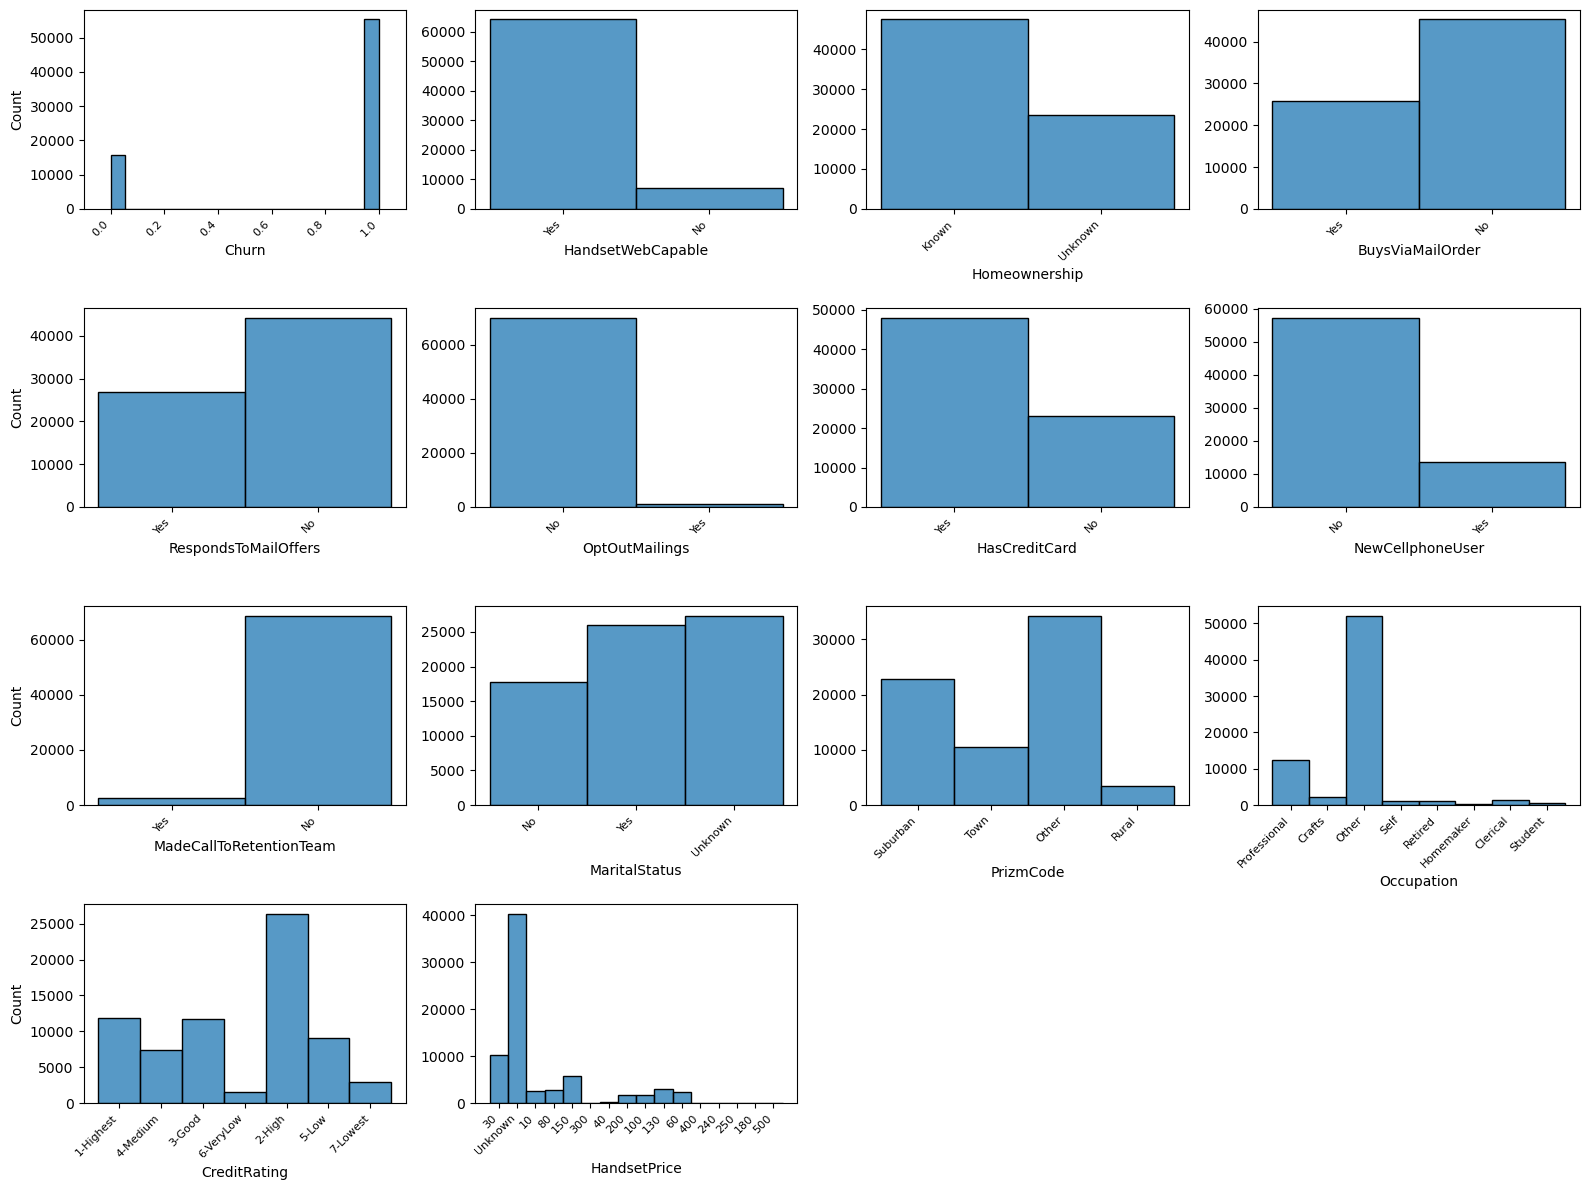

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(4, 4, figsize = (16, 12))

# Crear un histograma múltiple
sns.histplot(ax = axis[0, 0], data = df2, x = "Churn").set_xlim(-0.1, 1.1)
sns.histplot(ax = axis[0, 1], data = df2, x = "HandsetWebCapable").set(ylabel = None)
sns.histplot(ax = axis[0, 2], data = df2, x = "Homeownership").set(ylabel = None)
sns.histplot(ax = axis[0, 3], data = df2, x = "BuysViaMailOrder").set(ylabel = None)
sns.histplot(ax = axis[1, 0], data = df2, x = "RespondsToMailOffers")
sns.histplot(ax = axis[1, 1], data = df2, x = "OptOutMailings").set(ylabel = None)
sns.histplot(ax = axis[1, 2], data = df2, x = "HasCreditCard").set(ylabel = None)
sns.histplot(ax = axis[1, 3], data = df2, x = "NewCellphoneUser").set(ylabel = None)
sns.histplot(ax = axis[2, 0], data = df2, x = "MadeCallToRetentionTeam")
sns.histplot(ax = axis[2, 1], data = df2, x = "MaritalStatus").set(ylabel = None)
sns.histplot(ax = axis[2, 2], data = df2, x = "PrizmCode").set(ylabel = None)
sns.histplot(ax = axis[2, 3], data = df2, x = "Occupation").set(ylabel = None)
sns.histplot(ax = axis[3, 0], data = df2, x = "CreditRating")
sns.histplot(ax = axis[3, 1], data = df2, x = "HandsetPrice").set(ylabel = None)
sns.histplot(ax = axis[3, 2]).set_visible(False) # Ocultar el último subplot vacío
sns.histplot(ax = axis[3, 3]).set_visible(False) # Ocultar el último subplot vacío

# Rotar etiquetas del eje X en todos los subplots para evitar solapamientos de las etiquetas de los gráficos
for ax in axis.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    # Alinear texto
    plt.setp(ax.get_xticklabels(), ha='right')


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Churn: segun lo observado los clientes que No se dan de baja superan por mas del doble a los que si.
- HandsetWebCapable: hay minoría de clientes con dispositivos que no navegan en internet.
- Homeownership: no arroja información clara.
- BuysViaMailOrder: la mayoría de los clientes (2/3) no realizan compras por catalogos/correo.
- RespondsToMailOffers: los valores son similares a la categoría anterior.
- OptOutMailings: practicamente ningún cliente se ha dado de baja de recibir correspondencia publicitaria.
- HasCreditCard: la mayoría de clientes (2/3) poseen activas tarjetas de credito.
- NewCellphoneUser: alrededor de un 20% son nuevos usuarios de telefonía movil.
- MadeCallToRetentionTeam: muy pocos clientes han llamado al equipo de retención de la compañía.  
- MaritalStatus: no arroja información clara, aparentemente hay un porcentaje importante que no se sabe su situación marital.
- PrizmCode: de la mitad de los clientes no contamos con la información del tipo de zona donde reside, de la otra mitad sabemos que la mayoría se     encuentra ubicada en zonas suburbanas y el sobrante se reparte entre pueblo y rural.  
- Occupation: alrededor de 1000 clientes estan categorizados como profesionales, del resto la mayoría desconocemos su profesión
- CreditRating: la mitad de clientes tienen un alto riesgo de impago.
- HandsetPrice: de 40000 clientes no conocemos esta información (unknown), es decir no conocemos el precio de su equipo.






#### Análisis sobre variables numéricas

- MonthlyRevenue: Ingreso mensual generado por el cliente
- MonthlyMinutes: Minutos de uso mensual
- TotalRecurringCharge:	Cargo fijo recurrente mensual (cuota del plan)
- DirectorAssistedCalls: Cargos por llamadas asistidas por operadora
- OverageMinutes: Minutos consumidos por encima del plan contratado
- RoamingCalls:	Llamadas realizadas en roaming
- PercChangeMinutes: Variación porcentual de minutos respecto al periodo anterior
- PercChangeRevenues: Variación porcentual de ingresos respecto al periodo anterior
- DroppedCalls:	Llamadas caídas (cortadas)
- BlockedCalls: Llamadas bloqueadas (no se pudieron completar)
- CustomerCareCalls: Llamadas al servicio de atención al cliente
- ReceivedCalls: Llamadas recibidas
- OutboundCalls: Llamadas salientes
- InboundCalls:	Llamadas entrantes
- MonthsInService: Meses que el cliente lleva con la compañía (antigüedad)
- ActiveSubs: Número de líneas actualmente activas
- RetentionCalls: Número de llamadas al departamento de retención
- RetentionOffersAccepted: Número de ofertas de retención aceptadas
- IncomeGroup: Grupo/rango de ingresos del hogar (numérica pero funcionalmente ordinal)


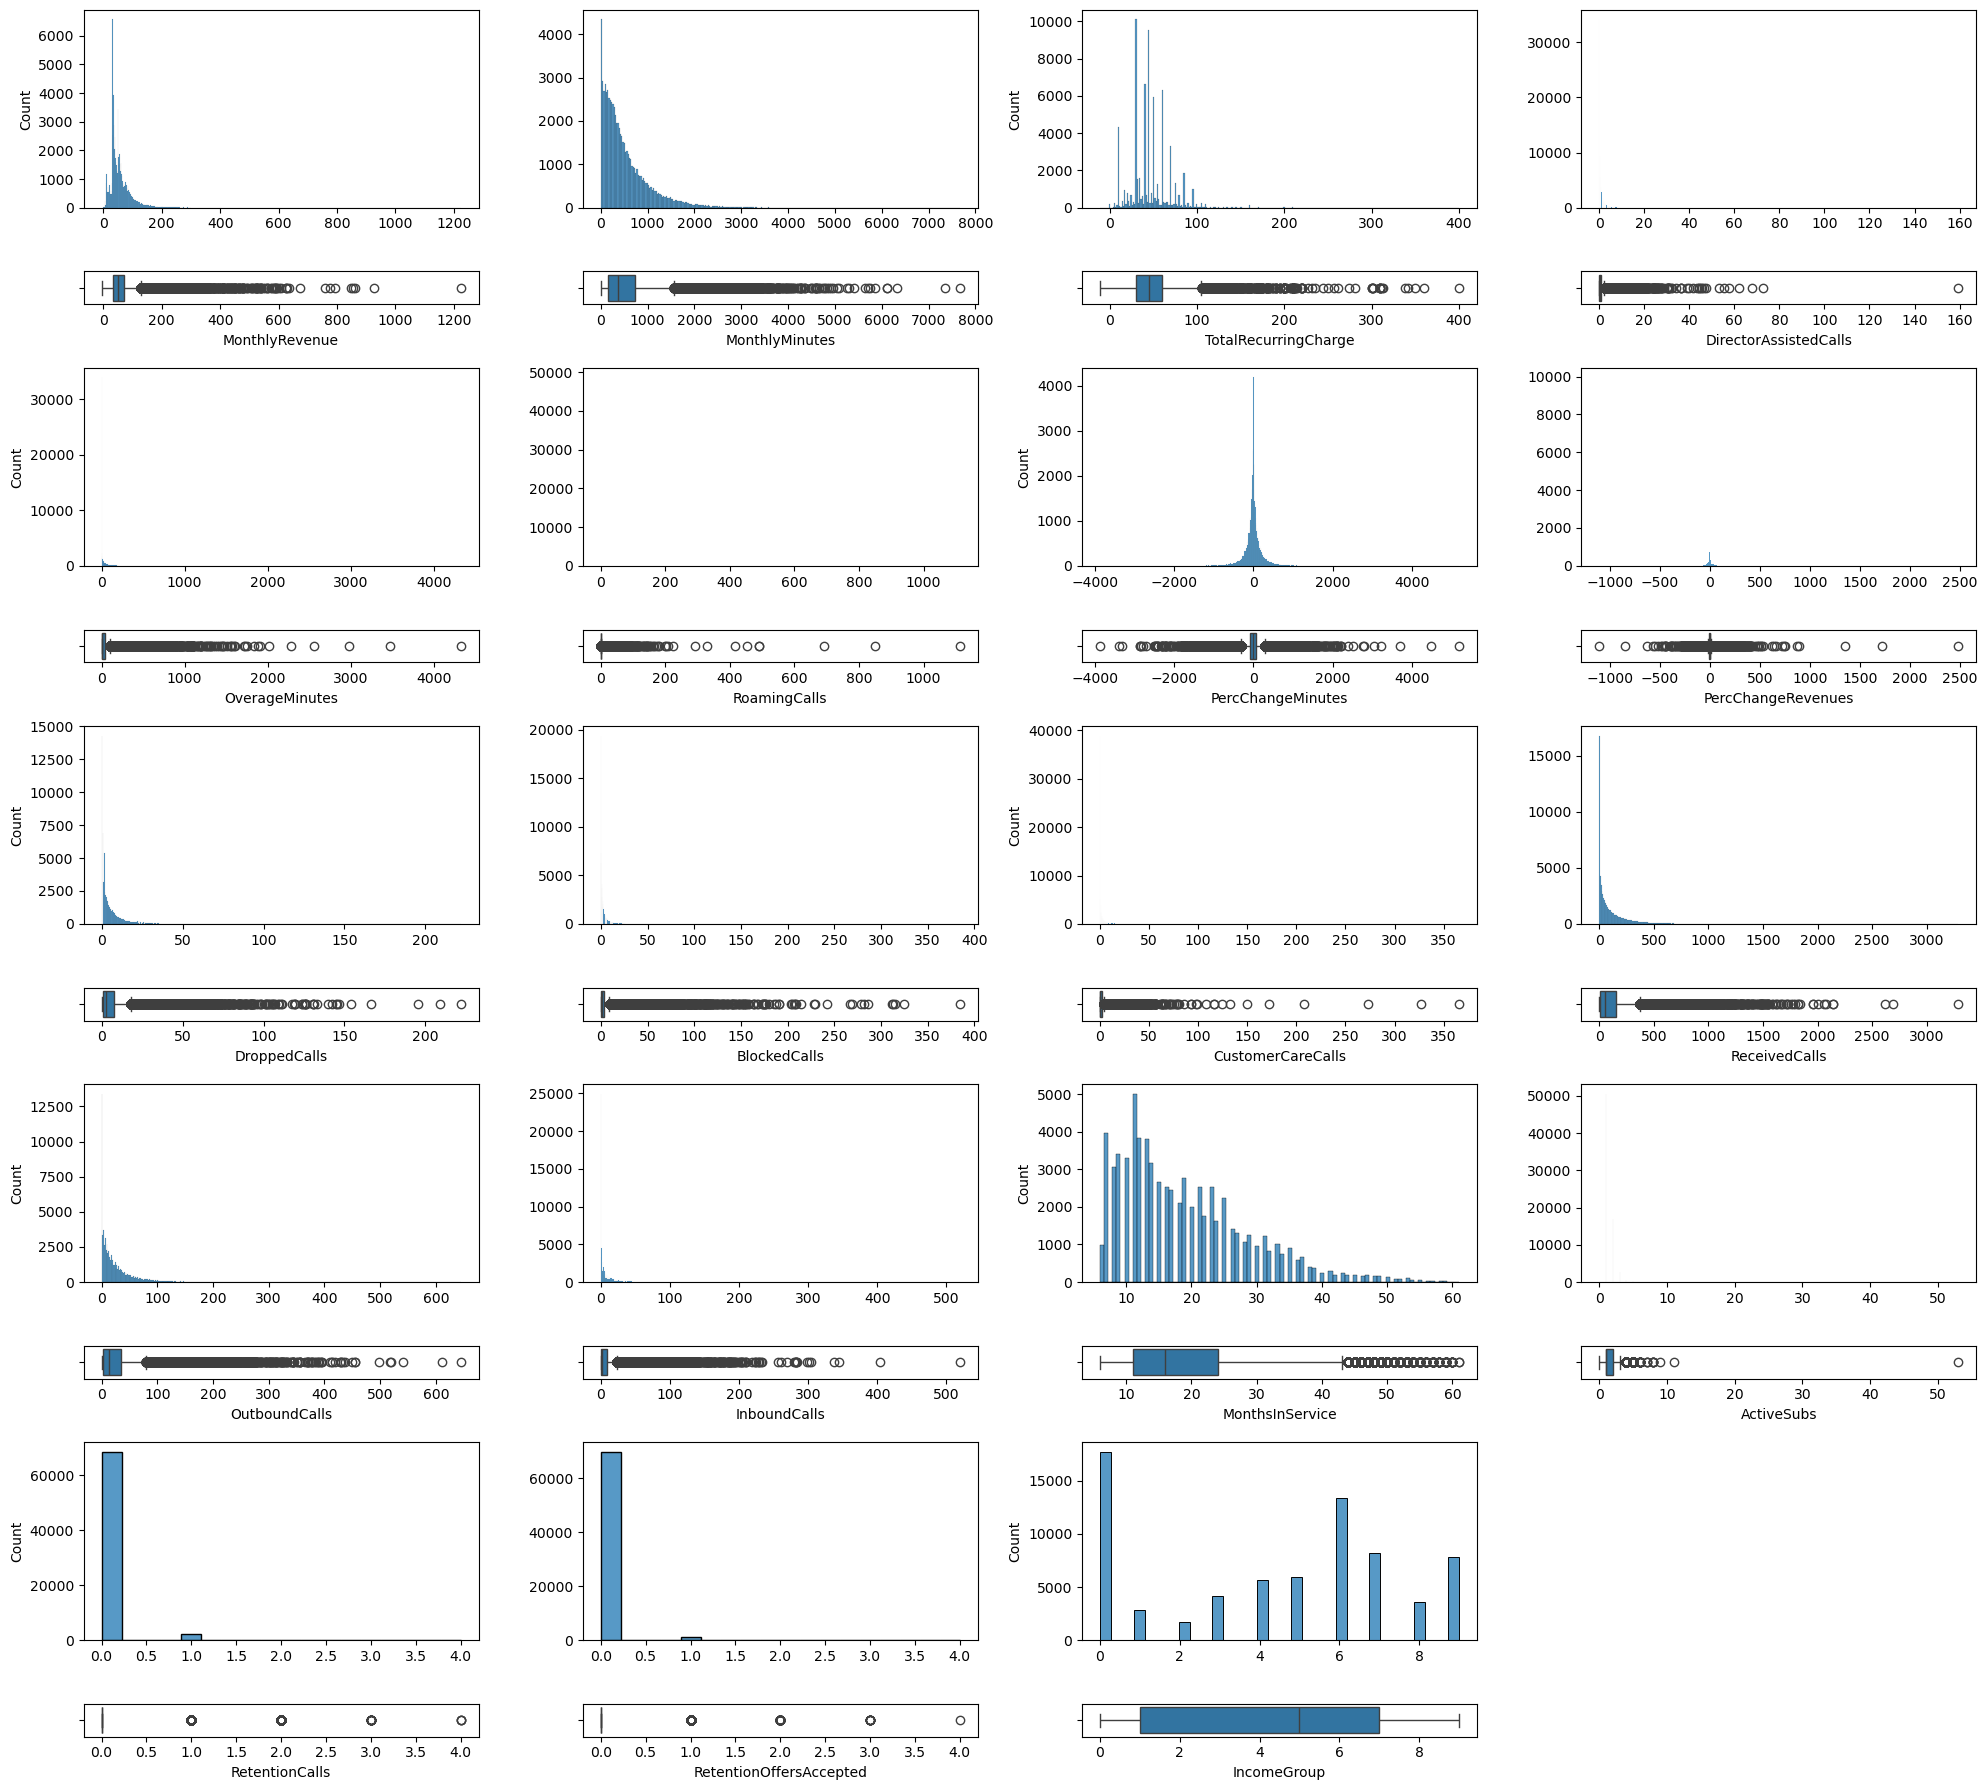

In [29]:
fig, axis = plt.subplots(10, 4, figsize = (20, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1, 6, 1, 6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = df2, x = "MonthlyRevenue").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df2, x = "MonthlyRevenue")
sns.histplot(ax = axis[0, 1], data = df2, x = "MonthlyMinutes").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df2, x = "MonthlyMinutes")
sns.histplot(ax = axis[0, 2], data = df2, x = "TotalRecurringCharge").set(xlabel = None)
sns.boxplot(ax = axis[1, 2], data = df2, x = "TotalRecurringCharge")
sns.histplot(ax = axis[0, 3], data = df2, x = "DirectorAssistedCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 3], data = df2, x = "DirectorAssistedCalls")

sns.histplot(ax = axis[2, 0], data = df2, x = "OverageMinutes").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = df2, x = "OverageMinutes")
sns.histplot(ax = axis[2, 1], data = df2, x = "RoamingCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df2, x = "RoamingCalls")
sns.histplot(ax = axis[2, 2], data = df2, x = "PercChangeMinutes").set(xlabel = None)
sns.boxplot(ax = axis[3, 2], data = df2, x = "PercChangeMinutes")
sns.histplot(ax = axis[2, 3], data = df2, x = "PercChangeRevenues").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 3], data = df2, x = "PercChangeRevenues")

sns.histplot(ax = axis[4, 0], data = df2, x = "DroppedCalls").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = df2, x = "DroppedCalls")
sns.histplot(ax = axis[4, 1], data = df2, x = "BlockedCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = df2, x = "BlockedCalls")
sns.histplot(ax = axis[4, 2], data = df2, x = "CustomerCareCalls").set(xlabel = None)
sns.boxplot(ax = axis[5, 2], data = df2, x = "CustomerCareCalls")
sns.histplot(ax = axis[4, 3], data = df2, x = "ReceivedCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 3], data = df2, x = "ReceivedCalls")

sns.histplot(ax = axis[6, 0], data = df2, x = "OutboundCalls").set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = df2, x = "OutboundCalls")
sns.histplot(ax = axis[6, 1], data = df2, x = "InboundCalls").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 1], data = df2, x = "InboundCalls")
sns.histplot(ax = axis[6, 2], data = df2, x = "MonthsInService").set(xlabel = None)
sns.boxplot(ax = axis[7, 2], data = df2, x = "MonthsInService")
sns.histplot(ax = axis[6, 3], data = df2, x = "ActiveSubs").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 3], data = df2, x = "ActiveSubs")

sns.histplot(ax = axis[8, 0], data = df2, x = "RetentionCalls").set(xlabel = None)
sns.boxplot(ax = axis[9, 0], data = df2, x = "RetentionCalls")
sns.histplot(ax = axis[8, 1], data = df2, x = "RetentionOffersAccepted").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[9, 1], data = df2, x = "RetentionOffersAccepted")
sns.histplot(ax = axis[8, 2], data = df2, x = "IncomeGroup").set(xlabel = None)
sns.boxplot(ax = axis[9, 2], data = df2, x = "IncomeGroup")
axis[8, 3].set_visible(False) # Ocultar los 2 últimos espacios ya que no hay gráficos para ellos
axis[9, 3].set_visible(False)



# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Conclusiones de los gráficos

- Monthly Revenue: La gran mayoría de usuarios generan unos ingresos mensuales de menos de 200 dólares para la compañía. Encontramos una minoría que genera por encima de esa cantidad hasta los 600 dólares. Aparece alguna excepción extremadamente inusual por encima de los 1000 dólares también.

- Monthly Minutes: La mayoría de la gente apenas hace llamadas, o directamente no hace uso de este servicio a lo largo del mes. el grueso de la gente usa menos de 1000 minutos al mes, y a partir de ahí, se ve como la cantidad de gente que gasta tantos minutos se reduce hasta que llegamos a la gente que usa 2000 minutos.

- Total recurring charge: La mayoría de gente tiene un cargo mensual alrededor de 50 dólares. Existe alguna excepción que supera los 100 dólares.

- Director assisted calls: Las llamadas con asistencia de operador prácticamente no son usadas.

- Overage minutes: Son los minutos que consume un cliente por encima del límite de su tarifa. Como se puede ver, muchísima gente no excede el límite de minutos.

- Roaming calls: Llamadas realizadas en el extranjero. De nuevo, es un servicio que mucha gente no usa.

- Per change minutes: La variación porcentual de minutos usados con respecto al mes anterior. Se trata de un gráfico bastante simétrico, donde vemos que la mayoría de gente gasta prácticamente los mismos minutos de un mes a otro. 

- Per change revenues: Variación de ingresos que genera un cliente a la compañía con respecto al mes anterior. De nuevo un gráfico muy simétrico que nos da a entender que los clientes suelen aportar la misma cantidad de ingresos a la compañía a lo largo de los meses.

- Dropped calls: Llamadas cortadas o perdidas. la mayoría de la gente no tiene llamadas de este tipo.

- Blocked calls: Llamadas bloqueadas, al igual que en el gráfico anterior, vemos que la mayoría de clientes no tienen llamadas bloqueadas.

- Customer care calls: Llamadas al servicio de atención al cliente. Mucha gente no llama al servicio, de hecho, no se registran ni 1000 llamadas al mes.

- Received calls: Llamadas recibidas por un cliente. La gran mayoría de clientes no tienen ni una llamada al mes. De los que sí reciben llamadas, muchos rondan la cantidad de 100 llamadas aproximadamente.

- Outbound calls: Llamadas salientes. Igual que con el gráfico anterior vemos que mucha gente no hace ni una sola llamada en todo el mes. De la gente que sí, muchos no llegan a las 50 llamadas mensuales. 

- Inbound calls: Llamadas entrantes. Resulta muy similar al resto de gráficos, donde vemos que una inmensa mayoría de clientes no tienen ni una llamada entrante a lo largo de un mes.

- Months in service: Antigüedad del cliente en meses. La mayoría ronda entre 10 y 25 meses. A partir de ahí vemos algunas excepciones de más de 40 meses.

- Active subs: Suscripciones activas del cliente. Vemos que mucha gente tiene menos de 5. 

- Retention calls: Llamadas con el departamento de retención que intenta evitar que se den de baja. No se registra prácticamente ni una sola de estas llamadas en todo un mes. 

- Retention offers accepted: Ofertas de retención aceptadas por clientes. Prácticamente no se registra ni una, lo cual tiene sentido al ver el gráfico anterior y ver que directamente no se producen las llamadas.

- Income group: Por desgracia no nos aporta mucha información al no poder acceder a la información de que representa el número de cada grupo.



#### Variables multivariante
Vamos a ver la relación entre algunas variables numéricas. Como Churn ha sido factorizada, podemos considerarla como tal. 

Vamos a concentrarnos en ver si la cantidad de llamadas y minutos usados por los clientes y lo que pagaban al mes por el servicio pudieron ser determinantes a la hora de hacer que se diera de baja. 

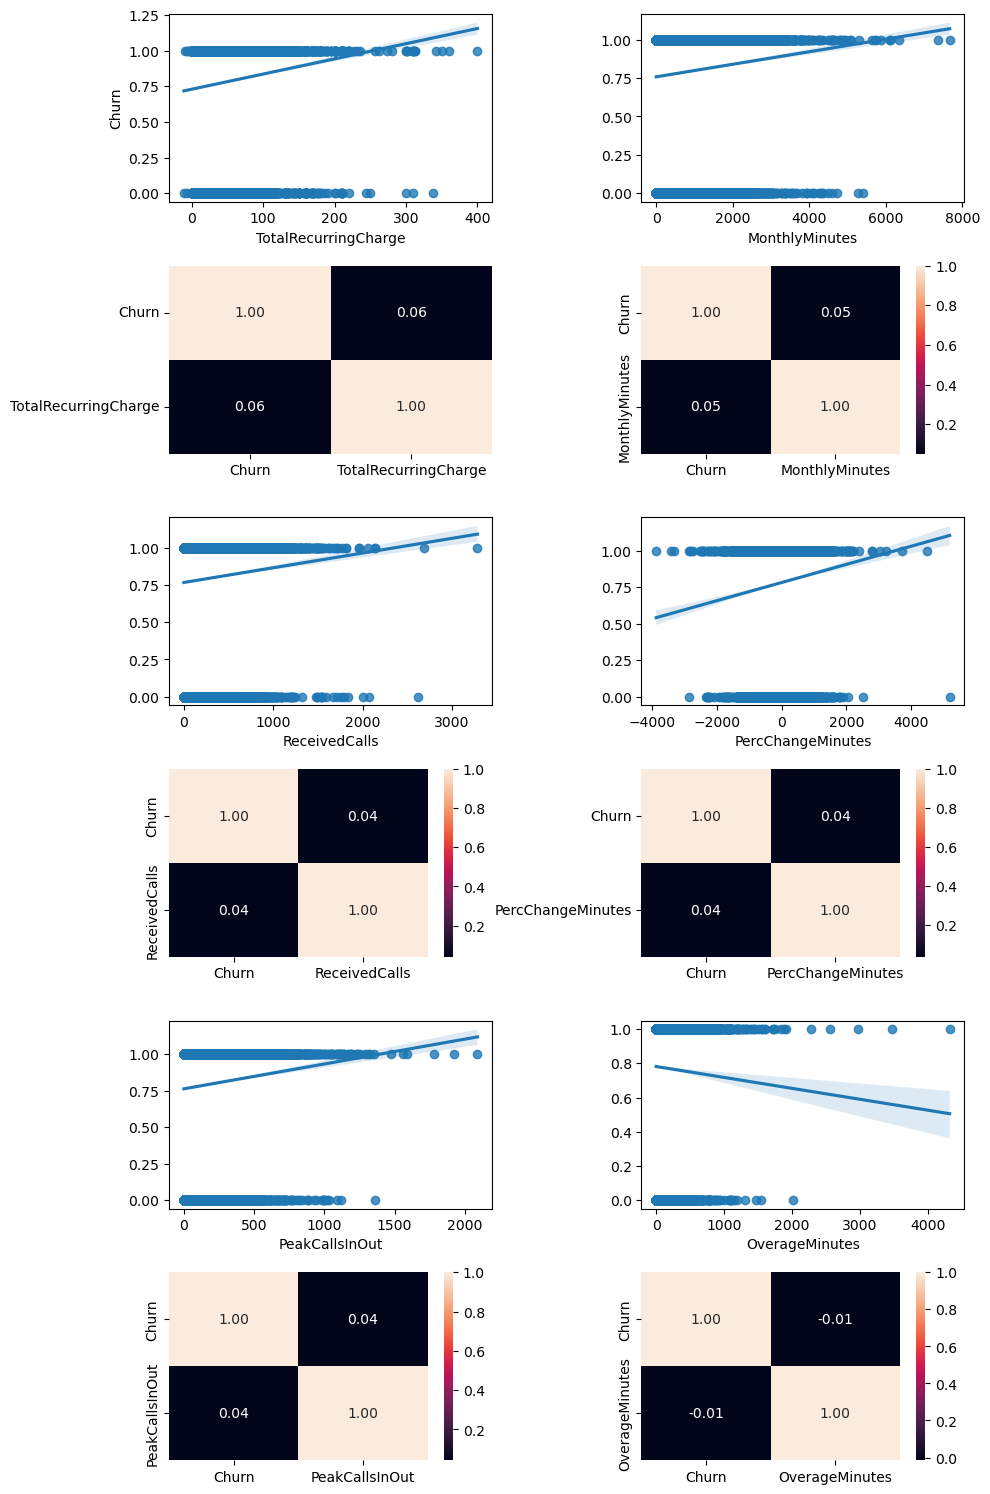

In [30]:
fig, axis = plt.subplots(6, 2, figsize = (10, 15))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df2, x = "TotalRecurringCharge", y = "Churn")
sns.heatmap(df2[["Churn", "TotalRecurringCharge"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df2, x = "MonthlyMinutes", y = "Churn").set(ylabel=None)
sns.heatmap(df2[["Churn", "MonthlyMinutes"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = df2, x = "ReceivedCalls", y = "Churn").set(ylabel=None)
sns.heatmap(df2[["Churn", "ReceivedCalls"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0])

sns.regplot(ax = axis[2, 1], data = df2, x = "PercChangeMinutes", y = "Churn").set(ylabel=None)
sns.heatmap(df2[["Churn", "PercChangeMinutes"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1])

sns.regplot(ax = axis[4, 0], data = df2, x = "PeakCallsInOut", y = "Churn").set(ylabel=None)
sns.heatmap(df2[["Churn", "PeakCallsInOut"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 0])

sns.regplot(ax = axis[4, 1], data = df2, x = "OverageMinutes", y = "Churn").set(ylabel=None)
sns.heatmap(df2[["Churn", "OverageMinutes"]].corr(), annot = True, fmt = ".2f", ax = axis[5, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Vemos que en todos los casos existe una relación directa entre las variables y el Churn, aunque es extremadamente débil.

La única variable con una relación negativa es la de los minutos gastados por encima del límite de la tarifa, que de nuevo es demasiado débil para tenerla en cuenta.

No parece que ninguna de las variables analizadas sea determinante a la hora de que un cliente decida darse de baja del servicio.

#### Análisis categórico - categórico 

Vamos a ver si los clientes hicieron llamadas al servicio de retención, su estabilidad financiera y si eran usuarios nuevos de móviles, ya que pueden tener comportamientos más atípicos que aquellos que ya llevan un tiempo o que al no ser estables financieramente puedan verse obligados a darse de baja de repente.

También vamos a ver si eran propietarios de algún tipo de inmueble, que puede llevarnos a hacernos una idea de su poder adquisitivo y de su estilo de vida.

In [31]:
df2['Churn'].value_counts()

Churn
1    55346
0    15701
Name: count, dtype: int64

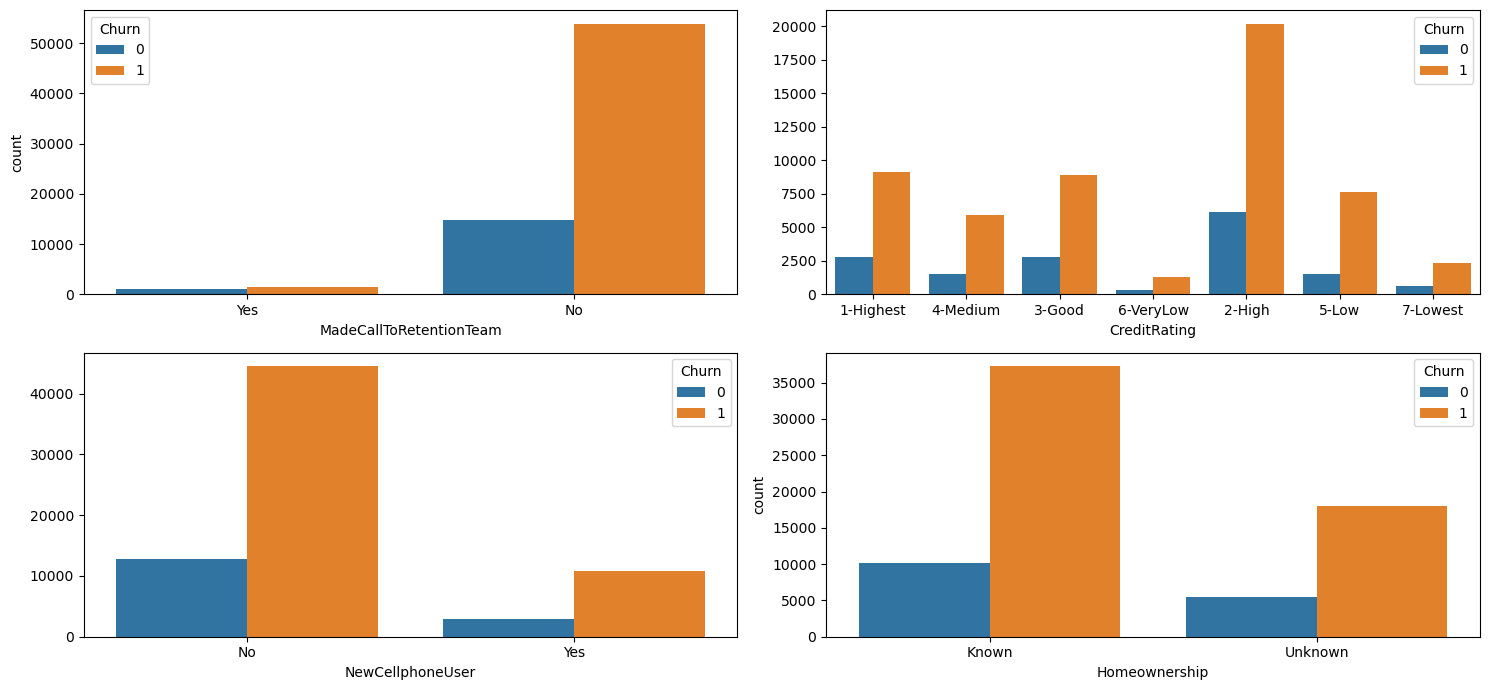

In [32]:
fig, axis = plt.subplots(2, 2, figsize = (15, 7))

sns.countplot(ax = axis[0, 0], data = df2, x = "MadeCallToRetentionTeam", hue = "Churn")
sns.countplot(ax = axis[0, 1], data = df2, x = "CreditRating", hue = "Churn").set(ylabel = None)
sns.countplot(ax = axis[1, 0], data = df2, x = "NewCellphoneUser", hue = "Churn").set(ylabel = None)
sns.countplot(ax = axis[1, 1], data = df2, x = "Homeownership", hue = "Churn")


plt.tight_layout()


plt.show()

Podemos confirmar la información que teníamos de antes: mucha gente no habla con el servicio de retención antes de darse de baja.

Como es de esperar, mucha gente que se da de baja pertenece a un grupo con un alto riesgo de inestabilidad financiera.

Mucha gente que se da de baja no son usuarios de móviles nuevos. 

Home ownership no nos aporta mucha información, ya que solo indica si se sabe o no que la persona es propietaria. 

#### Combinaciones de la clase con varias predictoras 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\2820167332.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0].set_xticklabels(axis[0].get_xticklabels(), rotation=45, ha='right')  # Rotar etiquetas del eje X para el primer gráfico


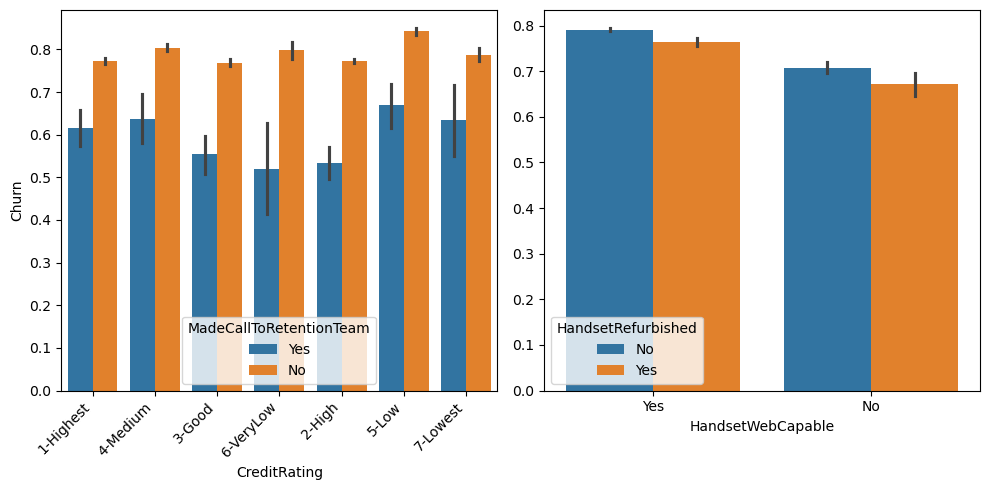

In [33]:
fig, axis = plt.subplots(figsize = (10, 5), ncols = 2)

sns.barplot(ax=axis[0], data=df2, x="CreditRating", y="Churn", hue="MadeCallToRetentionTeam")
axis[0].set_xticklabels(axis[0].get_xticklabels(), rotation=45, ha='right')  # Rotar etiquetas del eje X para el primer gráfico
sns.barplot(ax = axis[1], data = df2, x = "HandsetWebCapable", y = "Churn", hue = "HandsetRefurbished").set(ylabel = None)

plt.tight_layout()

plt.show()

El primer gráfico nos confirma una vez más la inexistencia de llamadas con retención de cliente y como los clientes con más inestabilidad financiera son los más propensos a darse de baja del servicio. 

El segundo gráfico nos muestra si los dispositivos, además de ser capaces o no de navegar por internet, son reacondicionados. Esto podría hacer que el cliente se sintiera a disgusto por su terminal y decidiera darse de baja. Como el gráfico muestra, la mayoría de gente que se da de baja tienen móviles de primera mano capaces de navegar por internet, por lo que nuestra hipótesis ha errado. 

#### Análisis de correlaciones 

Para esta parte del análisis tocará hacer la factorización de las columnas no numéricas. 

In [34]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71047 entries, 0 to 71046
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      71047 non-null  int64  
 1   MonthlyRevenue             70831 non-null  float64
 2   MonthlyMinutes             70831 non-null  float64
 3   TotalRecurringCharge       70831 non-null  float64
 4   DirectorAssistedCalls      70831 non-null  float64
 5   OverageMinutes             70831 non-null  float64
 6   RoamingCalls               70831 non-null  float64
 7   PercChangeMinutes          70545 non-null  float64
 8   PercChangeRevenues         70545 non-null  float64
 9   DroppedCalls               71047 non-null  float64
 10  BlockedCalls               71047 non-null  float64
 11  UnansweredCalls            71047 non-null  float64
 12  CustomerCareCalls          71047 non-null  float64
 13  ThreewayCalls              71047 non-null  flo

columnas a factorizar:
ServiceArea, ChildrenInHH, HandsetRefurbished ,HandsetWebCapable  ,TruckOwner, RVOwner, Homeownership, BuysViaMailOrder, RespondsToMailOffers, OptOutMailings, NonUSTravel, OwnsComputer, HasCreditCard, NewCellphoneUser, OwnsMotorcycle, HandsetPrice, MadeCallToRetentionTeam, CreditRating, PrizmCode, Occupation, MaritalStatus 

In [35]:


# factorizamos las columnas no numéricas de df2, guardando el resultado en una columna nueva con sufijo "_n"
for col in df2.columns:                                    # recorremos las columnas del dataframe
    if not pd.api.types.is_numeric_dtype(df2[col]):        # comprobamos si la columna no es numérica
        codigos, valores_unicos = pd.factorize(df2[col])   # separamos la factorizacion en 2 variables para crear el diccionario de reglas 
                                                           # de transformacion
        df2[col + "_n"] = codigos                     # guardamos la factorizacion en una columna nueva con el sufijo "_n" para indicar que es numerica

        # regla de transformacion de la columna
        reglas_columna = {valor: int(codigo) for codigo, valor in enumerate(valores_unicos)}

        # con el diccionario creado, lo guardamos en un json que tiene el nombre de la columna para identificarla
        with open(f"./{col}_transformation_rules.json", "w") as f:
            json.dump(reglas_columna, f)

df2.info() # info para comprobar que se han creado las columnas numericas debidamente factorizadas 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71047 entries, 0 to 71046
Data columns (total 76 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      71047 non-null  int64  
 1   MonthlyRevenue             70831 non-null  float64
 2   MonthlyMinutes             70831 non-null  float64
 3   TotalRecurringCharge       70831 non-null  float64
 4   DirectorAssistedCalls      70831 non-null  float64
 5   OverageMinutes             70831 non-null  float64
 6   RoamingCalls               70831 non-null  float64
 7   PercChangeMinutes          70545 non-null  float64
 8   PercChangeRevenues         70545 non-null  float64
 9   DroppedCalls               71047 non-null  float64
 10  BlockedCalls               71047 non-null  float64
 11  UnansweredCalls            71047 non-null  float64
 12  CustomerCareCalls          71047 non-null  float64
 13  ThreewayCalls              71047 non-null  flo

la factorización ha sido un éxito, ahora podemos ver las correlaciones.

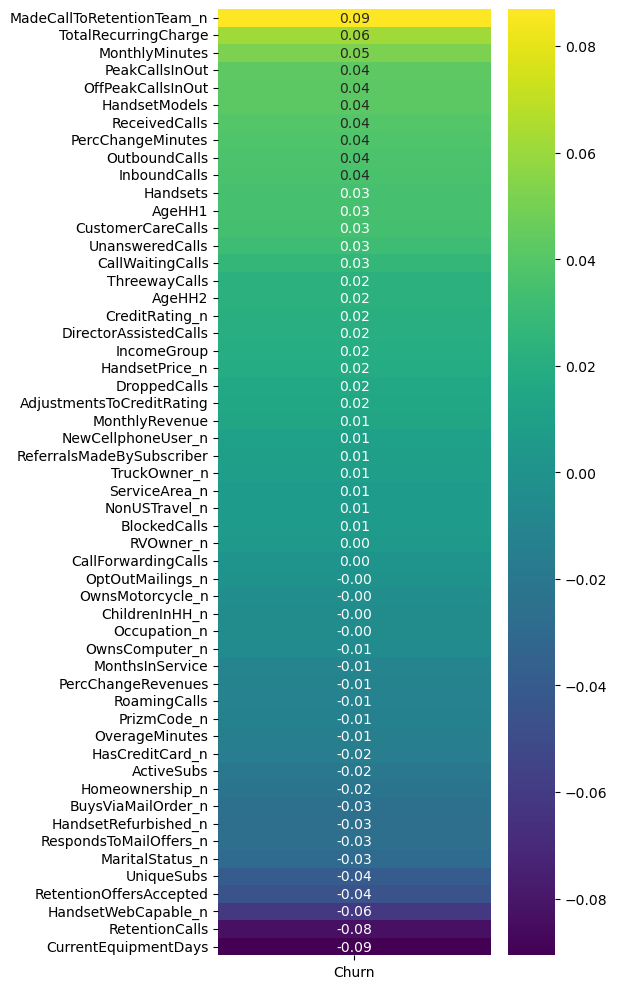

In [36]:
#Como solo nos interesa la correlación de las variables numéricas con la variable objetivo Churn, 
# vamos a crear un dataframe con todas las columnas numéricas de df2 y después calcularemos la correlación de cada columna con Churn.

cols_num = [col for col in df2.columns if pd.api.types.is_numeric_dtype(df2[col])]  # lista con todas las columnas numéricas de df2
correlaciones_churn = df2[cols_num].corr(method="pearson")['Churn'].drop('Churn').sort_values(ascending=False) # calculamos correlaciones con Churn 
                                                                                                               # y ordenamos de mayor a menor

#graficamos el heatmap en una sola columna. Un heatmap normal y corriente con tantas variables sería imposible de visualizar claramente
fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(correlaciones_churn.to_frame(), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

Exista una correlación inversa o directa entre Churn y cualquier otra variable, podemos ver que nunca llega a ser lo bastante fuerte como para poder ser tomada como un dato relevante.

In [37]:
#sns.pairplot(data = df2) 

## Ingeniería de características

### Análisis de outliers

In [38]:
#imprimir todas las columnas numericas
cols_num_filtradas = [col for col in cols_num if col != 'Churn' and "_n" not in col]  # lista con todas las columnas numéricas de df2, excluyendo Churn
                                                                                    # y las factorizadas 
cols_num_filtradas

['MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'AgeHH1',
 'AgeHH2',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'ReferralsMadeBySubscriber',
 'IncomeGroup',
 'AdjustmentsToCreditRating']

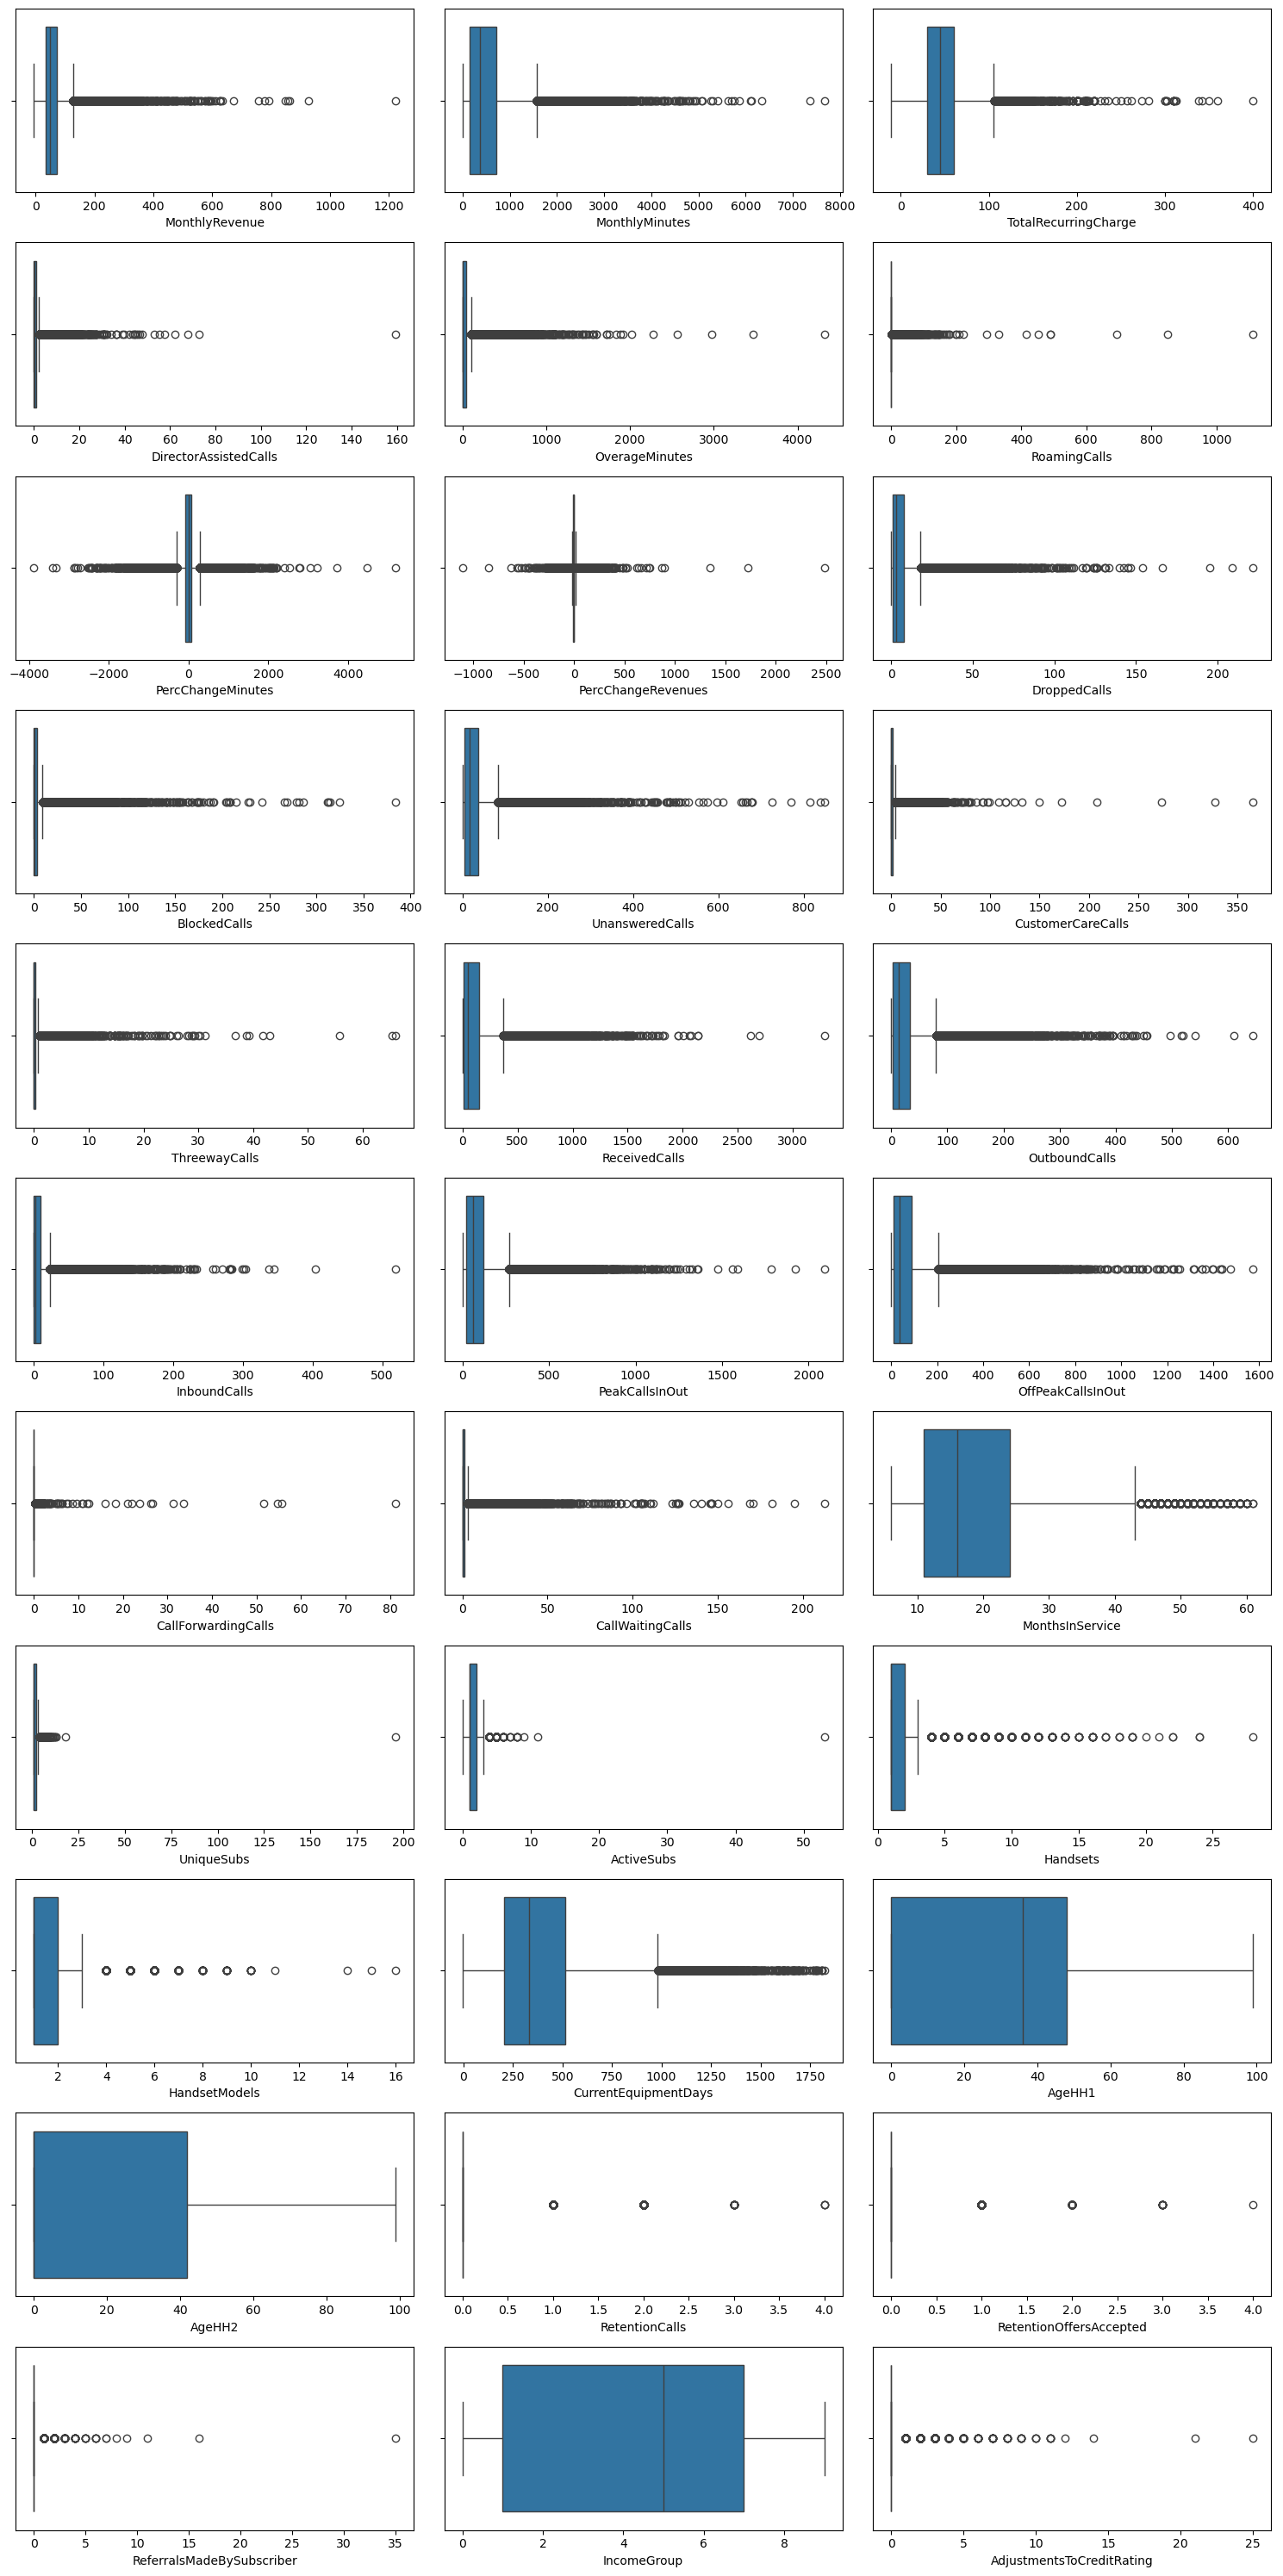

In [39]:
#Visualizar los outliers de las variables numéricas (cols_num) con boxplots (van a ser 33 boxplots en total)
#Ignoraremos las variables categóricas factorizadas para este paso (aquellas con sufijo "_n")

fig, axis = plt.subplots(11, 3, figsize=(15, 30)) #11 filas de 3 graficos cada una

cant_cols = 0 #contador de columnas numéricas que vamos a graficar
for i in range(11): #11 filas
    for j in range(3): #3 columnas
        if cant_cols < len(cols_num_filtradas):                                   #si el contador de columnas es menor que la cantidad de columnas numéricas
            sns.boxplot(ax=axis[i, j], data=df2, x=cols_num_filtradas[cant_cols]) #graficamos el boxplot de la columna numérica correspondiente
            cant_cols += 1                                              #incrementamos el contador de columnas
        else:                                                           #si ya no hay más columnas numéricas que graficar
            axis[i, j].set_visible(False)                               #ocultamos el subplot vacío

plt.tight_layout()
plt.show()

Las únicas variables sin outliers son: 

- AgeHH1

- AgeHH2

- IncomeGroup

Esto tiene todo el sentido porque son variables que se han colado superando el filtro anterior, pero en realidad son categóricas, igual que Churn. Antes de seguir vamos a sacarlas de la lista con la que estamos trabajando.

In [40]:
#Sacar AgeHH1, AgeHH2 e IcomeGroup de la lista de columnas numéricas filtradas
cols_num_filtradas.remove('AgeHH1')
cols_num_filtradas.remove('AgeHH2')
cols_num_filtradas.remove('IncomeGroup')
cols_num_filtradas                         #Comprobamos que la lista ya solo tiene las variables con outliers

['MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'ReferralsMadeBySubscriber',
 'AdjustmentsToCreditRating']

Puesto que vamos a usar un modelo de xgboost podría interesarnos conservar los outliers, así que crearemos un dataframe adicional que será el que no los tendrá.

In [41]:
df2_sin_outliers = df2.copy() #creamos una copia de df2 para limpiar los outliers sin perder el df2 original


for col in cols_num_filtradas: #recorremos la lista de columnas numéricas filtradas

    col_stats = df2_sin_outliers[col].describe() # stats de la columna
    col_iqr = col_stats['75%'] - col_stats['25%'] #sacamos iqr

    lower_limit = col_stats['25%'] - 1.5 * col_iqr #calculamos el límite inferior para los outliers
    upper_limit = col_stats['75%'] + 1.5 * col_iqr #calculamos el límite superior para los outliers

    print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(col_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 127.12 y -22.44, con un rango intercuartílico de 37.39
Los límites superior e inferior para la búsqueda de outliers son 1568.0 y -688.0, con un rango intercuartílico de 564.0
Los límites superior e inferior para la búsqueda de outliers son 105.0 y -15.0, con un rango intercuartílico de 30.0
Los límites superior e inferior para la búsqueda de outliers son 2.47 y -1.48, con un rango intercuartílico de 0.99
Los límites superior e inferior para la búsqueda de outliers son 102.5 y -61.5, con un rango intercuartílico de 41.0
Los límites superior e inferior para la búsqueda de outliers son 0.75 y -0.45, con un rango intercuartílico de 0.3
Los límites superior e inferior para la búsqueda de outliers son 289.5 y -306.5, con un rango intercuartílico de 149.0
Los límites superior e inferior para la búsqueda de outliers son 14.65 y -20.15, con un rango intercuartílico de 8.7
Los límites superior e inferior para la búsqueda de outlier

In [42]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = df2.copy()
total_data_SIN_outliers = df2.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

# usamos cols_num_filtradas

def replace_outliers(column, df):
  col_stats = df[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in cols_num_filtradas:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'MonthlyRevenue': [-6.17, 127.12],
 'MonthlyMinutes': [0.0, 1568.0],
 'TotalRecurringCharge': [-11.0, 105.0],
 'DirectorAssistedCalls': [0.0, 2.47],
 'OverageMinutes': [0.0, 102.5],
 'RoamingCalls': [0.0, 0.75],
 'PercChangeMinutes': [-3875.0, 289.5],
 'PercChangeRevenues': [-1107.7, 14.65],
 'DroppedCalls': [0.0, 18.2],
 'BlockedCalls': [0.0, 9.25],
 'UnansweredCalls': [0.0, 83.8],
 'CustomerCareCalls': [0.0, 4.25],
 'ThreewayCalls': [0.0, 0.75],
 'ReceivedCalls': [0.0, 372.65],
 'OutboundCalls': [0.0, 80.05],
 'InboundCalls': [0.0, 23.25],
 'PeakCallsInOut': [0.0, 268.38],
 'OffPeakCallsInOut': [0.0, 205.25],
 'CallForwardingCalls': [0.0, 0.0],
 'CallWaitingCalls': [0.0, 3.25],
 'MonthsInService': [6, 43.5],
 'UniqueSubs': [1, 3.5],
 'ActiveSubs': [0, 3.5],
 'Handsets': [1.0, 3.5],
 'HandsetModels': [1.0, 3.5],
 'CurrentEquipmentDays': [-5.0, 981.5],
 'RetentionCalls': [0.0, 0.0],
 'RetentionOffersAccepted': [0.0, 0.0],
 'ReferralsMadeBySubscriber': [0.0, 0.0],
 'AdjustmentsToCredit

In [43]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

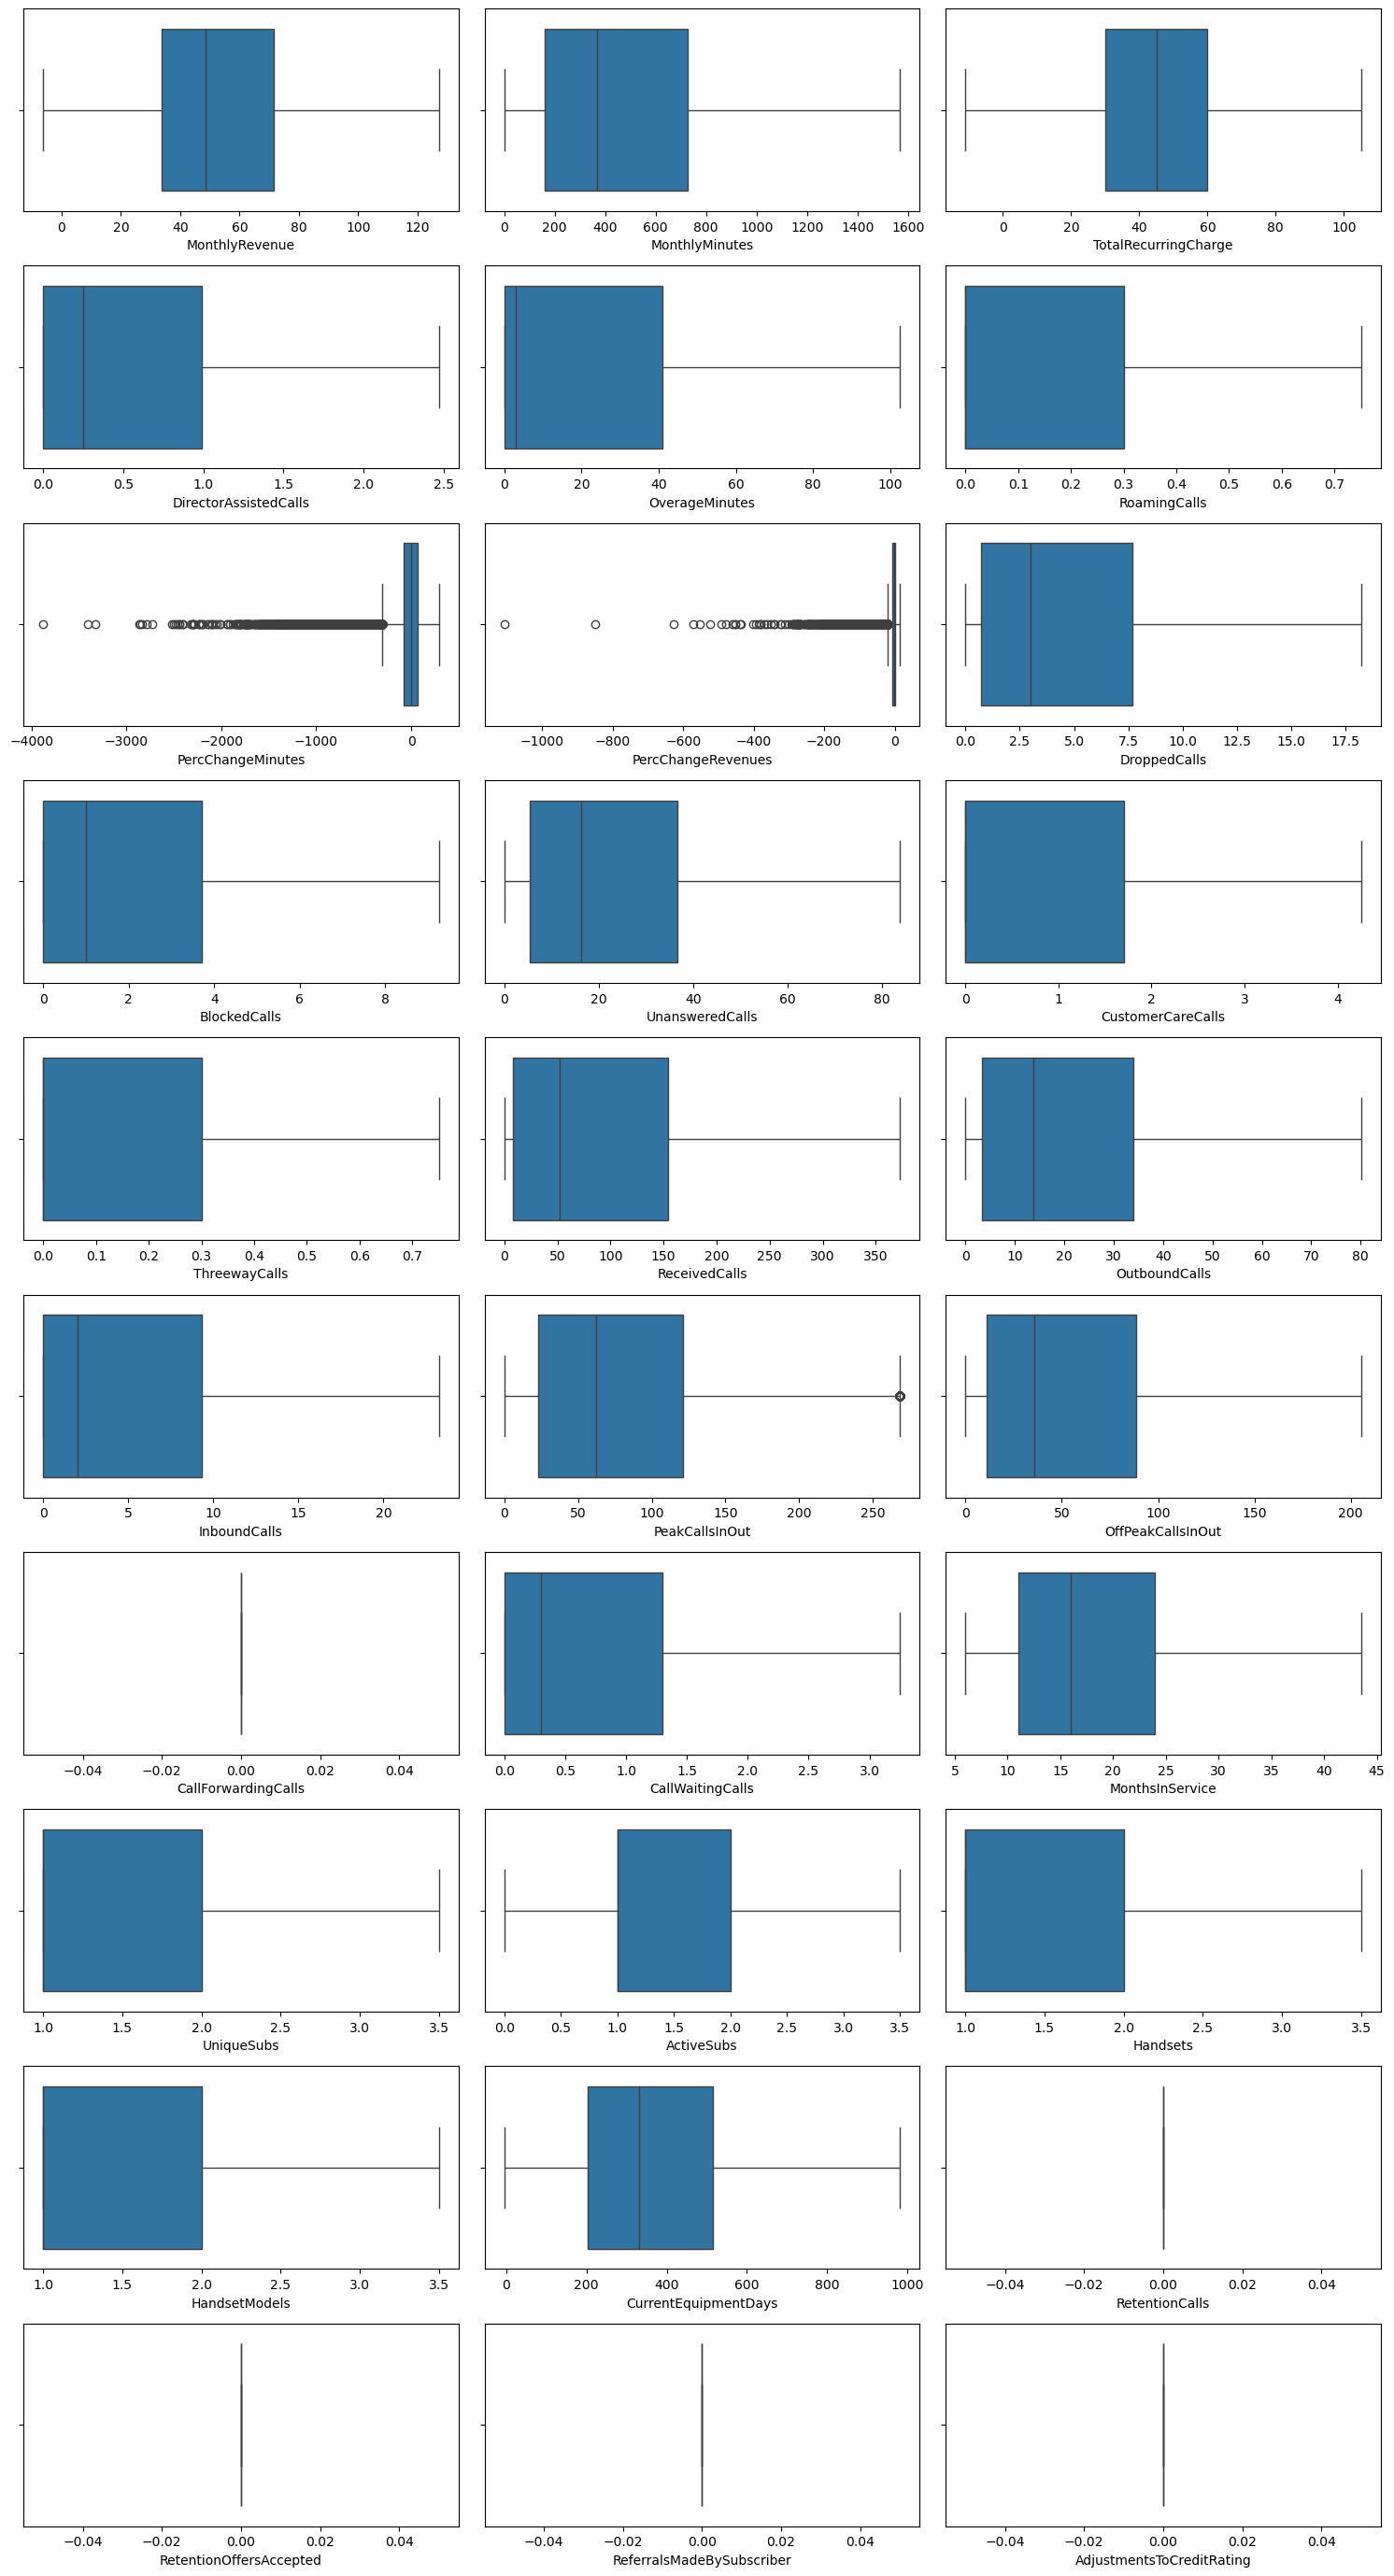

In [44]:
#volvemos a graficar para comprobar que los outliers se han ido 

fig, axis = plt.subplots(11, 3, figsize=(15, 30)) #11 filas de 3 graficos cada una

cant_cols = 0 
for i in range(11): #11 filas
    for j in range(3): #3 columnas
        if cant_cols < len(cols_num_filtradas):                            
            sns.boxplot(ax=axis[i, j], data=total_data_SIN_outliers, x=cols_num_filtradas[cant_cols]) 
            cant_cols += 1                                              
        else:                                                        
            axis[i, j].set_visible(False)                              

plt.tight_layout()
plt.show()

los outliers han sido eliminados en todas las variables menos Per Change Minutes y Revenue.

#### Tratamiento de valores nulos 

In [45]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

AgeHH1                       1244
AgeHH2                       1244
PercChangeRevenues            502
PercChangeMinutes             502
RoamingCalls                  216
                             ... 
MadeCallToRetentionTeam_n       0
CreditRating_n                  0
PrizmCode_n                     0
Occupation_n                    0
MaritalStatus_n                 0
Length: 76, dtype: int64

In [46]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

AgeHH1                       1244
AgeHH2                       1244
ServiceArea                    28
Churn                           0
DirectorAssistedCalls           0
                             ... 
MadeCallToRetentionTeam_n       0
CreditRating_n                  0
PrizmCode_n                     0
Occupation_n                    0
MaritalStatus_n                 0
Length: 76, dtype: int64

In [47]:
variables_con_nulos = total_data_CON_outliers.isnull().sum().sort_values(ascending=False)
variables_con_nulos

AgeHH1                       1244
AgeHH2                       1244
PercChangeRevenues            502
PercChangeMinutes             502
RoamingCalls                  216
                             ... 
MadeCallToRetentionTeam_n       0
CreditRating_n                  0
PrizmCode_n                     0
Occupation_n                    0
MaritalStatus_n                 0
Length: 76, dtype: int64

In [48]:
# Rellenar los valores de Age HH1 y Age HH2 con la moda  de la variable en ambos dataframes
total_data_CON_outliers["AgeHH1"] = total_data_CON_outliers["AgeHH1"].fillna(df2["AgeHH1"].mode()[0]) # Cuando una variable es categórica
total_data_CON_outliers["AgeHH2"] = total_data_CON_outliers["AgeHH2"].fillna(df2["AgeHH2"].mode()[0]) # Cuando una variable es categórica


total_data_SIN_outliers["AgeHH1"] = total_data_SIN_outliers["AgeHH1"].fillna(df2["AgeHH1"].mode()[0])
total_data_SIN_outliers["AgeHH2"] = total_data_SIN_outliers["AgeHH2"].fillna(df2["AgeHH2"].mode()[0])

In [49]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

PercChangeRevenues           502
PercChangeMinutes            502
MonthlyRevenue               216
MonthlyMinutes               216
RoamingCalls                 216
                            ... 
MadeCallToRetentionTeam_n      0
CreditRating_n                 0
PrizmCode_n                    0
Occupation_n                   0
MaritalStatus_n                0
Length: 76, dtype: int64

In [50]:
# Rellenar los valores nulos de las columnas numéricas con la media
numeric_cols_with_nulls = ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 
                           'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 
                           'PercChangeMinutes', 'PercChangeRevenues', 'Handsets', 
                           'HandsetModels', 'CurrentEquipmentDays']

for col in numeric_cols_with_nulls:
    mean_val = total_data_CON_outliers[col].mean()
    total_data_CON_outliers[col].fillna(mean_val, inplace=True)
    total_data_SIN_outliers[col].fillna(mean_val, inplace=True)

# Rellenar los valores nulos de ServiceArea con la moda (es categorica) 
service_area_mode = total_data_CON_outliers['ServiceArea'].mode()[0]
total_data_CON_outliers['ServiceArea'].fillna(service_area_mode, inplace=True)
total_data_SIN_outliers['ServiceArea'].fillna(service_area_mode, inplace=True)

# Verificar que no quedan nulos
print("Nulos en total_data_CON_outliers:")
print(total_data_CON_outliers.isnull().sum().sum())
print("\nNulos en total_data_SIN_outliers:")
print(total_data_SIN_outliers.isnull().sum().sum())

Nulos en total_data_CON_outliers:
0

Nulos en total_data_SIN_outliers:
0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\332746420.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  total_data_CON_outliers[col].fillna(mean_val, inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31972\332746420.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

#### Corrección de `ServiceArea_n` tras rellenar sus nulos

Al factorizar ServiceArea  lo hicimos antes de tratar sus nulos, así que las 28 filas que originalmente eran nulas se quedaron con un valor de -1. Vamos a corregir esto rellenando todos los -1 de ServiceArea_n con la moda de la variable. 


In [51]:
# recuperamos las reglas de factorizacion de ServiceArea que ya se guardaron en su json
with open("./ServiceArea_transformation_rules.json") as f:
    reglas_service_area = json.load(f)

# codigo que le corresponde a la moda, segun ese mismo mapeo
codigo_moda_service_area = reglas_service_area[service_area_mode]

# sustituimos el -1 (que representaba el nulo original) por el codigo de la moda, en ambos dataframes
total_data_CON_outliers.loc[total_data_CON_outliers['ServiceArea_n'] == -1, 'ServiceArea_n'] = codigo_moda_service_area
total_data_SIN_outliers.loc[total_data_SIN_outliers['ServiceArea_n'] == -1, 'ServiceArea_n'] = codigo_moda_service_area

# comprobacion: ya no deberia haber ningun -1 en ServiceArea_n
print("Filas con ServiceArea_n == -1 en CON_outliers:", (total_data_CON_outliers['ServiceArea_n'] == -1).sum())
print("Filas con ServiceArea_n == -1 en SIN_outliers:", (total_data_SIN_outliers['ServiceArea_n'] == -1).sum())


Filas con ServiceArea_n == -1 en CON_outliers: 0
Filas con ServiceArea_n == -1 en SIN_outliers: 0


## Split en test y train para entrenar modelo de ML

In [52]:


# ESTO ES LO QUE ENTRA EN ESTE PASO
# total_data_SIN_outliers
# total_data_CON_outliers

#Las predictoras son todas las variables menos Churn, vamos a recorrer el dataframe y añadirlas

predictoras = [col for col in total_data_CON_outliers.columns 
               if pd.api.types.is_numeric_dtype(total_data_CON_outliers[col]) #la columna debe ser numerica
               and col != "Churn"] # y no debe ser churn



target = "Churn"

X_CON = total_data_CON_outliers.drop(target, axis=1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis=1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size=0.2, random_state=10)
X_train_SIN_outliers, X_test_SIN_outliers, _, _ = train_test_split(X_SIN, y, test_size=0.2, random_state=10)

# ESTO ES LO QUE SALE DE ESTE PASO
# X_train_CON_outliers
# X_test_CON_outliers
# X_train_SIN_outliers
# X_test_SIN_outliers
# y_train
# y_test

#### Escalado de valores

In [53]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ESTO ES LO QUE ENTRA EN ESTE PASO
# X_train_CON_outliers
# X_test_CON_outliers
# X_train_SIN_outliers
# X_test_SIN_outliers
# y_train
# y_test

## NORMALIZACIÓN (cambiar valores para que tengan media de 0 y std de 1)
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN) (cambiar valores para que estén comprendidos entre 0 y 1)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# ESTO ES LO QUE SALE DE ESTE PASO
# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal
# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal
# y_train
# y_test

In [54]:
X_train_CON_outliers

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,OwnsComputer_n,HasCreditCard_n,NewCellphoneUser_n,OwnsMotorcycle_n,HandsetPrice_n,MadeCallToRetentionTeam_n,CreditRating_n,PrizmCode_n,Occupation_n,MaritalStatus_n
33775,59.99,285.0,70.0,0.00,0.0,0.0,77.0,0.0,0.0,0.0,...,1,1,1,0,1,1,4,1,2,2
10082,23.24,47.0,22.0,0.00,0.0,0.7,15.0,-20.3,2.0,1.3,...,1,1,0,0,1,1,4,2,2,1
57077,120.28,708.0,111.0,0.00,0.0,18.2,-200.0,-7.3,5.7,26.7,...,1,0,0,0,1,1,4,1,2,1
21471,51.38,60.0,56.0,0.00,0.0,0.0,-60.0,5.7,1.7,0.3,...,1,0,0,0,1,1,1,2,2,0
4999,121.86,1182.0,50.0,2.23,215.0,0.0,-432.0,-61.3,5.0,6.3,...,0,0,0,0,10,1,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17904,31.48,64.0,30.0,0.00,4.0,0.0,10.0,-1.5,1.0,0.7,...,1,0,0,0,1,1,4,2,2,1
37597,34.99,0.0,45.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,6,0,2,2
10201,10.00,36.0,10.0,0.00,0.0,0.0,22.0,0.0,0.7,0.0,...,0,0,0,0,0,1,0,2,0,1
9372,44.07,140.0,46.0,0.00,0.0,0.0,-43.0,12.9,3.3,0.0,...,0,0,0,0,1,1,0,0,0,1


In [55]:
X_train_CON_outliers_norm

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,OwnsComputer_n,HasCreditCard_n,NewCellphoneUser_n,OwnsMotorcycle_n,HandsetPrice_n,MadeCallToRetentionTeam_n,CreditRating_n,PrizmCode_n,Occupation_n,MaritalStatus_n
33775,0.024438,-0.453334,0.967921,-0.401879,-0.413087,-0.130823,0.342389,0.029774,-0.664026,-0.382499,...,0.477110,1.446663,2.048716,-0.117575,-0.448219,0.187685,0.614384,-0.265759,0.174893,1.103772
10082,-0.803560,-0.902109,-1.041191,-0.401879,-0.413087,-0.057075,0.100773,-0.488391,-0.443134,-0.260117,...,0.477110,1.446663,-0.488111,-0.117575,-0.448219,0.187685,0.614384,0.772953,0.174893,-0.170762
57077,1.382806,0.344279,2.684039,-0.401879,-0.413087,1.786631,-0.737089,-0.156561,-0.034484,2.131042,...,0.477110,-0.691246,-0.488111,-0.117575,-0.448219,0.187685,0.614384,-0.265759,0.174893,-0.170762
21471,-0.169550,-0.877597,0.381930,-0.401879,-0.413087,-0.130823,-0.191504,0.175269,-0.476268,-0.354257,...,0.477110,-0.691246,-0.488111,-0.117575,-0.448219,0.187685,-1.030343,0.772953,0.174893,-1.445295
4999,1.418404,1.238059,0.130791,0.600734,1.791316,-0.130823,-1.641200,-1.534932,-0.111796,0.210584,...,-2.095952,-0.691246,-0.488111,-0.117575,2.835452,0.187685,-0.482100,-1.304472,0.174893,-0.170762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17904,-0.617908,-0.870054,-0.706339,-0.401879,-0.372075,-0.130823,0.081288,-0.008514,-0.553580,-0.316601,...,0.477110,-0.691246,-0.488111,-0.117575,-0.448219,0.187685,0.614384,0.772953,0.174893,-0.170762
37597,-0.538826,-0.990733,-0.078491,-0.401879,-0.413087,-0.130823,0.042318,0.029774,-0.664026,-0.382499,...,0.477110,1.446663,-0.488111,-0.117575,-0.448219,0.187685,1.710868,-1.304472,0.174893,1.103772
10201,-1.101865,-0.922851,-1.543469,-0.401879,-0.413087,-0.130823,0.128053,0.029774,-0.586714,-0.382499,...,-2.095952,-0.691246,-0.488111,-0.117575,-0.813072,0.187685,-1.578585,0.772953,-1.569652,-0.170762
9372,-0.334249,-0.726748,-0.036635,-0.401879,-0.413087,-0.130823,-0.125255,0.359052,-0.299554,-0.382499,...,-2.095952,-0.691246,-0.488111,-0.117575,-0.448219,0.187685,-1.578585,-1.304472,-1.569652,-0.170762


In [56]:
X_train_CON_outliers_scal

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,OwnsComputer_n,HasCreditCard_n,NewCellphoneUser_n,OwnsMotorcycle_n,HandsetPrice_n,MadeCallToRetentionTeam_n,CreditRating_n,PrizmCode_n,Occupation_n,MaritalStatus_n
33775,0.053808,0.037167,0.197080,0.000000,0.000000,0.000000,0.435866,0.308448,0.000000,0.000000,...,1.0,1.0,1.0,0.0,0.066667,1.0,0.666667,0.333333,0.285714,1.0
10082,0.023919,0.006129,0.080292,0.000000,0.000000,0.000629,0.429028,0.302796,0.009021,0.003383,...,1.0,1.0,0.0,0.0,0.066667,1.0,0.666667,0.666667,0.285714,0.5
57077,0.102843,0.092332,0.296837,0.000000,0.000000,0.016361,0.405316,0.306416,0.025710,0.069477,...,1.0,0.0,0.0,0.0,0.066667,1.0,0.666667,0.333333,0.285714,0.5
21471,0.046806,0.007825,0.163017,0.000000,0.000000,0.000000,0.420757,0.310036,0.007668,0.000781,...,1.0,0.0,0.0,0.0,0.066667,1.0,0.166667,0.666667,0.285714,0.0
4999,0.104128,0.154147,0.148418,0.013991,0.049757,0.000000,0.379729,0.291379,0.022553,0.016393,...,0.0,0.0,0.0,0.0,0.666667,1.0,0.333333,0.000000,0.285714,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17904,0.030621,0.008346,0.099757,0.000000,0.000926,0.000000,0.428477,0.308031,0.004511,0.001821,...,1.0,0.0,0.0,0.0,0.066667,1.0,0.666667,0.666667,0.285714,0.5
37597,0.033476,0.000000,0.136253,0.000000,0.000000,0.000000,0.427374,0.308448,0.000000,0.000000,...,1.0,1.0,0.0,0.0,0.066667,1.0,1.000000,0.000000,0.285714,1.0
10201,0.013151,0.004695,0.051095,0.000000,0.000000,0.000000,0.429800,0.308448,0.003157,0.000000,...,0.0,0.0,0.0,0.0,0.000000,1.0,0.000000,0.666667,0.000000,0.5
9372,0.040860,0.018258,0.138686,0.000000,0.000000,0.000000,0.422632,0.312041,0.014885,0.000000,...,0.0,0.0,0.0,0.0,0.066667,1.0,0.000000,0.000000,0.000000,0.5


In [57]:
'''# GUARDARLO -> TODO <-

# RECORDAR HABER GUARDADO LOS JSONS DE LA FACTORIZACIÓN

# PATH = "/data/processed"
PATH = "."

# DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5
X_train_CON_outliers.to_excel(f"{PATH}/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel(f"{PATH}/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel(f"{PATH}/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel(f"{PATH}/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel(f"{PATH}/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel(f"{PATH}/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel(f"{PATH}/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel(f"{PATH}/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel(f"{PATH}/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel(f"{PATH}/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel(f"{PATH}/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel(f"{PATH}/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel(f"{PATH}/y_train.xlsx", index = False)
y_test.to_excel(f"{PATH}/y_test.xlsx", index = False)

# SCALERS
import pickle

# MODEL_PATH = "/model"
MODEL_PATH = "."

with open(f"{MODEL_PATH}/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open(f"{MODEL_PATH}/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open(f"{MODEL_PATH}/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open(f"{MODEL_PATH}/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)'''

'# GUARDARLO -> TODO <-\n\n# RECORDAR HABER GUARDADO LOS JSONS DE LA FACTORIZACIÓN\n\n# PATH = "/data/processed"\nPATH = "."\n\n# DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5\nX_train_CON_outliers.to_excel(f"{PATH}/X_train_CON_outliers.xlsx", index = False)\nX_train_CON_outliers_norm.to_excel(f"{PATH}/X_train_CON_outliers_norm.xlsx", index = False)\nX_train_CON_outliers_scal.to_excel(f"{PATH}/X_train_CON_outliers_scal.xlsx", index = False)\nX_train_SIN_outliers.to_excel(f"{PATH}/X_train_SIN_outliers.xlsx", index = False)\nX_train_SIN_outliers_norm.to_excel(f"{PATH}/X_train_SIN_outliers_norm.xlsx", index = False)\nX_train_SIN_outliers_scal.to_excel(f"{PATH}/X_train_SIN_outliers_scal.xlsx", index = False)\n\nX_test_CON_outliers.to_excel(f"{PATH}/X_test_CON_outliers.xlsx", index = False)\nX_test_CON_outliers_norm.to_excel(f"{PATH}/X_test_CON_outliers_norm.xlsx", index = False)\nX_test_CON_outliers_scal.to_excel(f"{PATH}/X_test_CON_outliers_scal.xlsx", index = False)\nX_test_SIN_outli

#### Selección de características 

In [59]:
from sklearn.feature_selection import f_classif, SelectKBest

X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

# Con un valor de k = 5 decimos implícitamente que queremos eliminar 2 características del conjunto de datos
selection_model = SelectKBest(f_classif, k = 10)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,MonthlyMinutes,TotalRecurringCharge,PeakCallsInOut,OffPeakCallsInOut,HandsetModels,CurrentEquipmentDays,RetentionCalls,RetentionOffersAccepted,HandsetWebCapable_n,MadeCallToRetentionTeam_n
0,285.0,70.0,0.0,0.0,1.0,384.0,0.0,0.0,0.0,1.0
1,47.0,22.0,17.3,4.7,1.0,744.0,0.0,0.0,0.0,1.0
2,708.0,111.0,125.7,18.3,1.0,571.0,0.0,0.0,0.0,1.0
3,60.0,56.0,12.7,10.3,1.0,574.0,0.0,0.0,0.0,1.0
4,1182.0,50.0,249.7,155.3,4.0,272.0,0.0,0.0,0.0,1.0


In [62]:
#Correlacion con Churn de las variables en X_train_sel
# Correlación de cada variable con Churn
for col in X_train_sel.columns:
    correlacion = X_train_sel[col].corr(y_train, method="pearson")
    print(col, correlacion)

MonthlyMinutes 0.00010064408666240622
TotalRecurringCharge -0.002563372588369498
PeakCallsInOut 0.00047922133027173097
OffPeakCallsInOut -0.00289291559653257
HandsetModels -0.010091276068450826
CurrentEquipmentDays -0.0007758971663950294
RetentionCalls -0.007262190278296526
RetentionOffersAccepted -0.00941488529958312
HandsetWebCapable_n 0.006765116113086831
MadeCallToRetentionTeam_n 0.0077842679055813305


In [ ]:
# lista de variables predictoras que tengan una correlacion con churn de >0.04  o < -0.04

lista_predictoras_final = [                       #sacamos churn por razones obvias
    col for col in total_data_CON_outliers.drop(columns=["Churn"]).select_dtypes(include=['number']).columns #solo numericas
    if abs(total_data_CON_outliers[col].corr(y_train, method="pearson")) > 0.04                                  #and col != "Churn"
]

lista_predictoras_final

['MonthlyMinutes',
 'TotalRecurringCharge',
 'ReceivedCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'HandsetModels',
 'CurrentEquipmentDays',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'HandsetWebCapable_n',
 'MadeCallToRetentionTeam_n']

In [70]:
from xgboost import XGBClassifier # solo importo el modelo de clasificación, que es el que usaré

# Diccionarios de datasets , voy a hacerlo así para que al final se imprima el nombre del mejor dataset, y no el dataset en sí
datasets = {
    "X_CON_outliers": X_train_CON_outliers,
    "X_SIN_outliers": X_train_SIN_outliers,
}

test_datasets = {
    "X_CON_outliers": X_test_CON_outliers,
    "X_SIN_outliers": X_test_SIN_outliers,
}

# Entrenar modelos de xgboost con los diferentes datasets y calcular accuracy
models = {} #ahora esto pasa a ser diccionarios para poder ser coherente y adjuntar el dataset con su nombre y su accuracy
metrics = {}

for name, dataset in datasets.items():
    model = XGBClassifier(random_state=10)  # random state fijo para todos los modelos y que se puedan comparar
    model.fit(dataset, y_train)
    y_pred = model.predict(dataset)
    metric = accuracy_score(y_train, y_pred)
    
    models[name] = model  #en el diccionario de modelos guardo el modelo entrenado con su nombre
    metrics[name] = metric  #en el diccionario de metrics guardo la métrica de accuracy con el nombre del dataset correspondiente

# Selección del mejor dataset
best_name = max(metrics, key=metrics.get)  #busco en el diccionario de metrics el nombre del dataset con la mejor métrica y lo guardo
best_dataset = datasets[best_name] #con el nombre del mejor dataset busco el dataset en sí en el diccionario de datasets y lo guardo
best_test_dataset = test_datasets[best_name] #ahora hago lo mismo en el diccionario de los datasets de test

print(f"El mejor dataset es {best_name}")

El mejor dataset es X_SIN_outliers


In [ ]:
model = XGBClassifier(
    objective='binary:logistic',  
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


# Realizamos el grid search

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',        
    cv=2,                     
    n_jobs=-1,
    verbose=2,
    refit=True
)

# ahora entrenamos el modelo  del grid search
grid_search.fit(X_train, y_train)


# imprimimos resultados del grid search

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print(f"\nMejor accuracy (CV): {grid_search.best_score_:.4f}")

# Modelo final ya entrenado con los mejores parámetros
best_model = grid_search.best_estimator_